In [32]:
from triqs.gf import *
from triqs.plot.mpl_interface import oplot
from h5 import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
cmap = plt.colormaps["hsv"]
%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi'] = 150
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rc('font', size=12)

In [33]:
data_loc = "/home/andrewhardy/Documents/CCQ/cthyb_dyn/benchmark/dynamic_int"
J = 1.0
U = 4.0

### CTSEG compared to CTHYB with only $J_\perp$ dynamical interactions

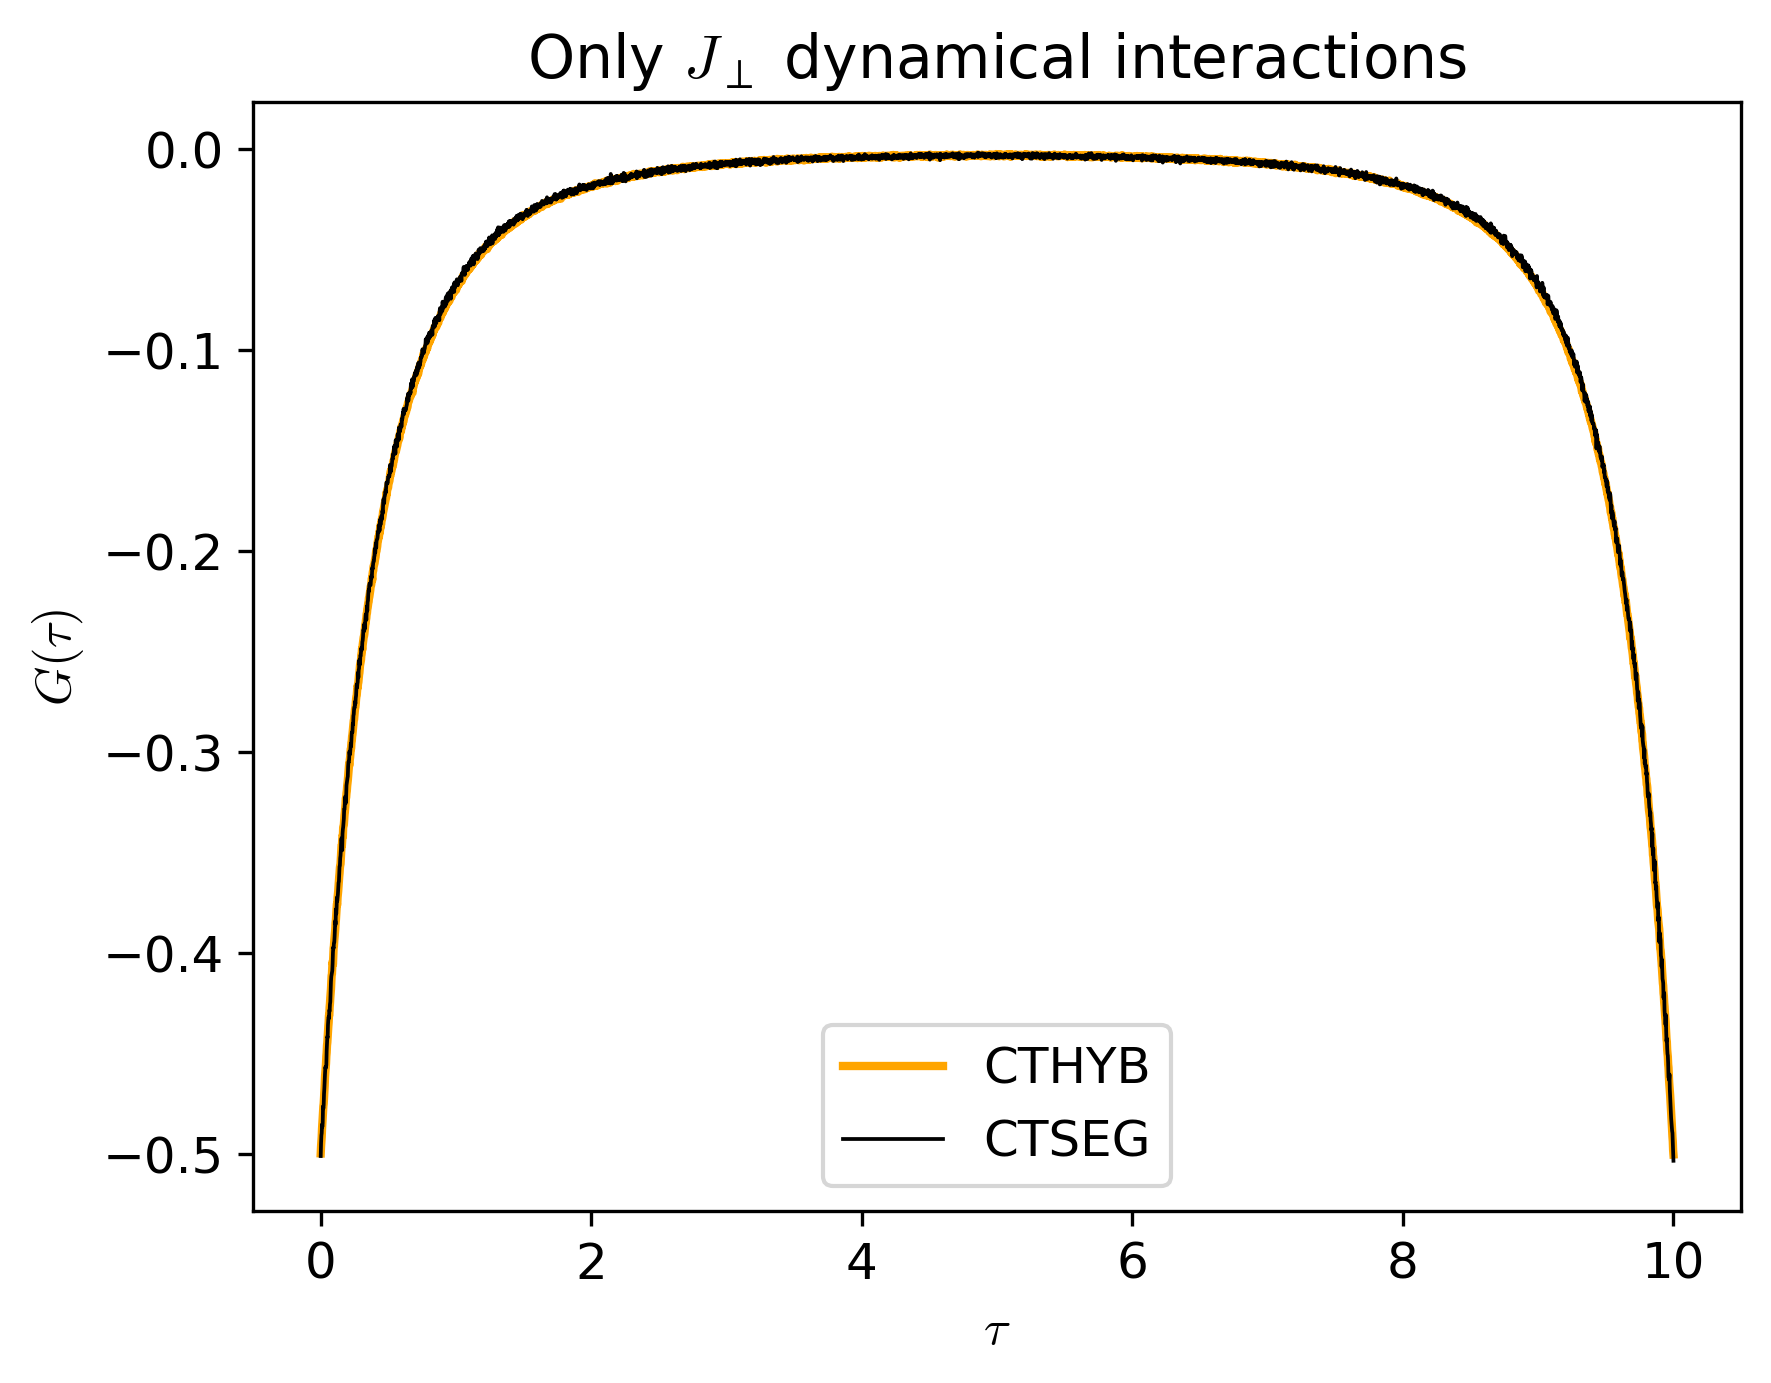

In [34]:
with HDFArchive(f"{data_loc}/ctint.ref.h5", "r") as A:
    G_tau_int = A["dmft_loop/i_001/S/G_tau"]

with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0_U-0.0_0.0_0.0_0.0.h5", "r") as A:
    G_tau_seg = A["G_tau"]
with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0_U-0.0_0.0_0.0_0.0.h5", "r") as A:
    G_tau_hyb = A["G_tau"]
with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-0.0_U-1.0_1.0_1.0_1.0.h5", "r") as A:
    G_tau_hyb_no_J = A["G_tau"] 

oplot(G_tau_hyb["up"].real, color="orange", linewidth = 2.0, label="CTHYB")
oplot(G_tau_seg["up"].real, color="black", linewidth = 0.9, label="CTSEG")
#oplot(G_tau_hyb_no_J["up"].real, color="blue", linewidth = 0.9, label="CTHYB no $J_\perp$")
plt.title(r"Only $J_\perp$ dynamical interactions")
plt.ylabel(r"$G(\tau)$")
plt.legend()
plt.show()

### CTSEG compared to CTHYB with only diagonal $D_0$ dynamical interactions

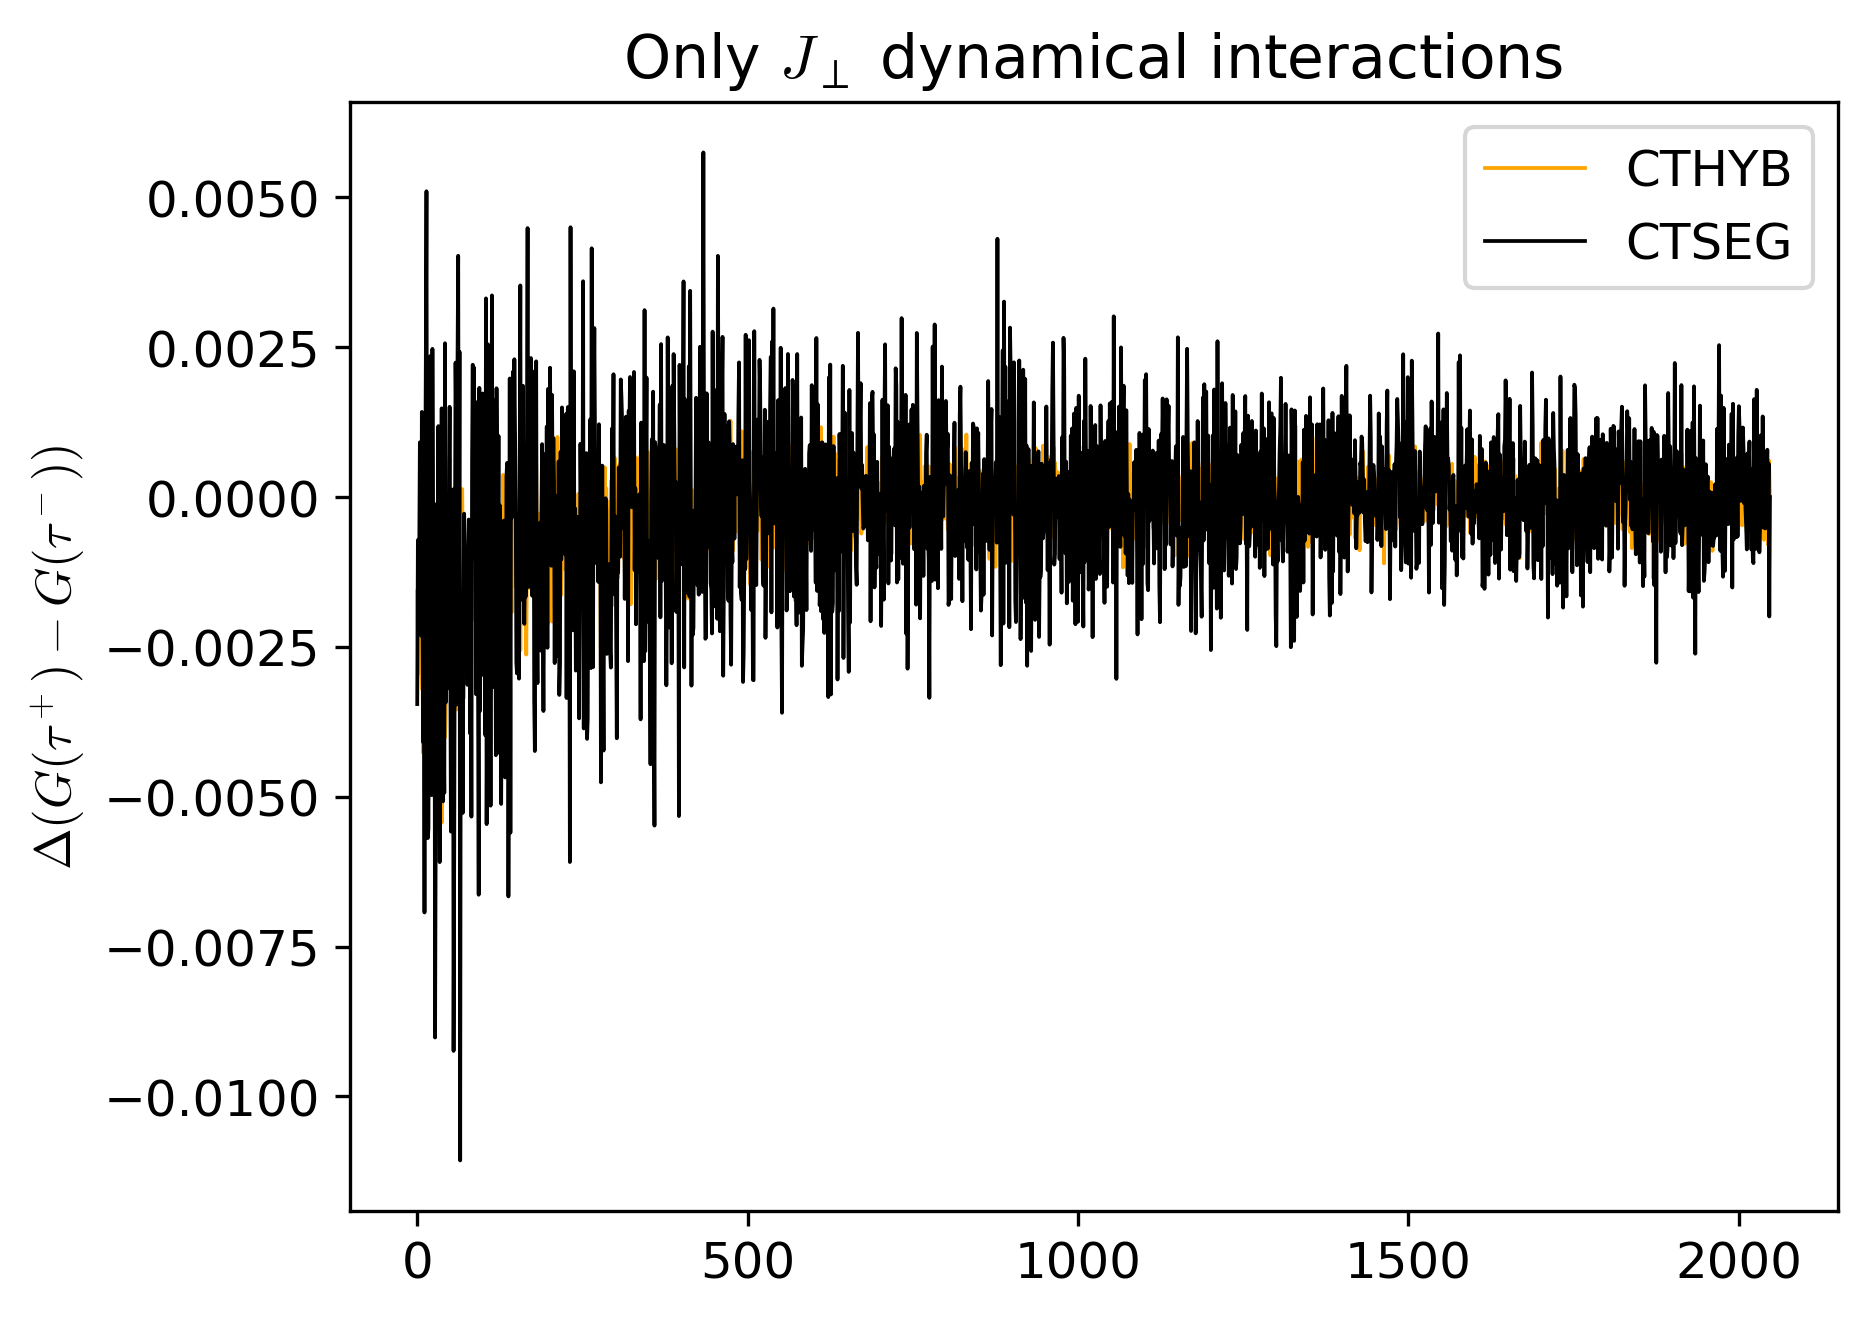

In [35]:
hyb_len = len(G_tau_hyb["up"].real.data)
seg_len = len(G_tau_seg["up"].real.data)

plt.plot(G_tau_hyb["up"].real.data[0:hyb_len//2,0,0]-np.flip(G_tau_hyb["up"].real.data[hyb_len//2-1:-1,0,0]), color="orange", linewidth = 0.9, label="CTHYB")
plt.plot(G_tau_seg["up"].real.data[0:seg_len//2,0,0]-np.flip(G_tau_seg["up"].real.data[seg_len//2-1:-1,0,0]), color="black", linewidth = 0.9, label="CTSEG")
plt.title(r"Only $J_\perp$ dynamical interactions")
plt.ylabel(r"$\Delta (G(\tau^+) - G(\tau^-))$")
plt.legend()
plt.show()

### CTSEG compared to CTHYB with full dynamical interactions

['G_tau', 'average_sign', 'densities', 'nn', 'nn_nu', 'nn_tau', 'perturbation_order_D', 'perturbation_order_J']
['G0_iw', 'G_iw', 'chiAB_tau']
['G_tau', 'O_tau', 'average_sign', 'perturbation_order', 'perturbation_order_dynamical']
0.73420728125 average sign


/home/andrewhardy/Documents/CCQ/installation/lib/python3.12/site-packages/h5/archive.py:232: UserWarning: The hdf5 format Histogram is not recognized. Returning as a group. Did you forgot to import this python class ?
  warnings.warn(f"The hdf5 format {hdf5_format} is not recognized. Returning as a group. Did you forgot to import this python class ?")


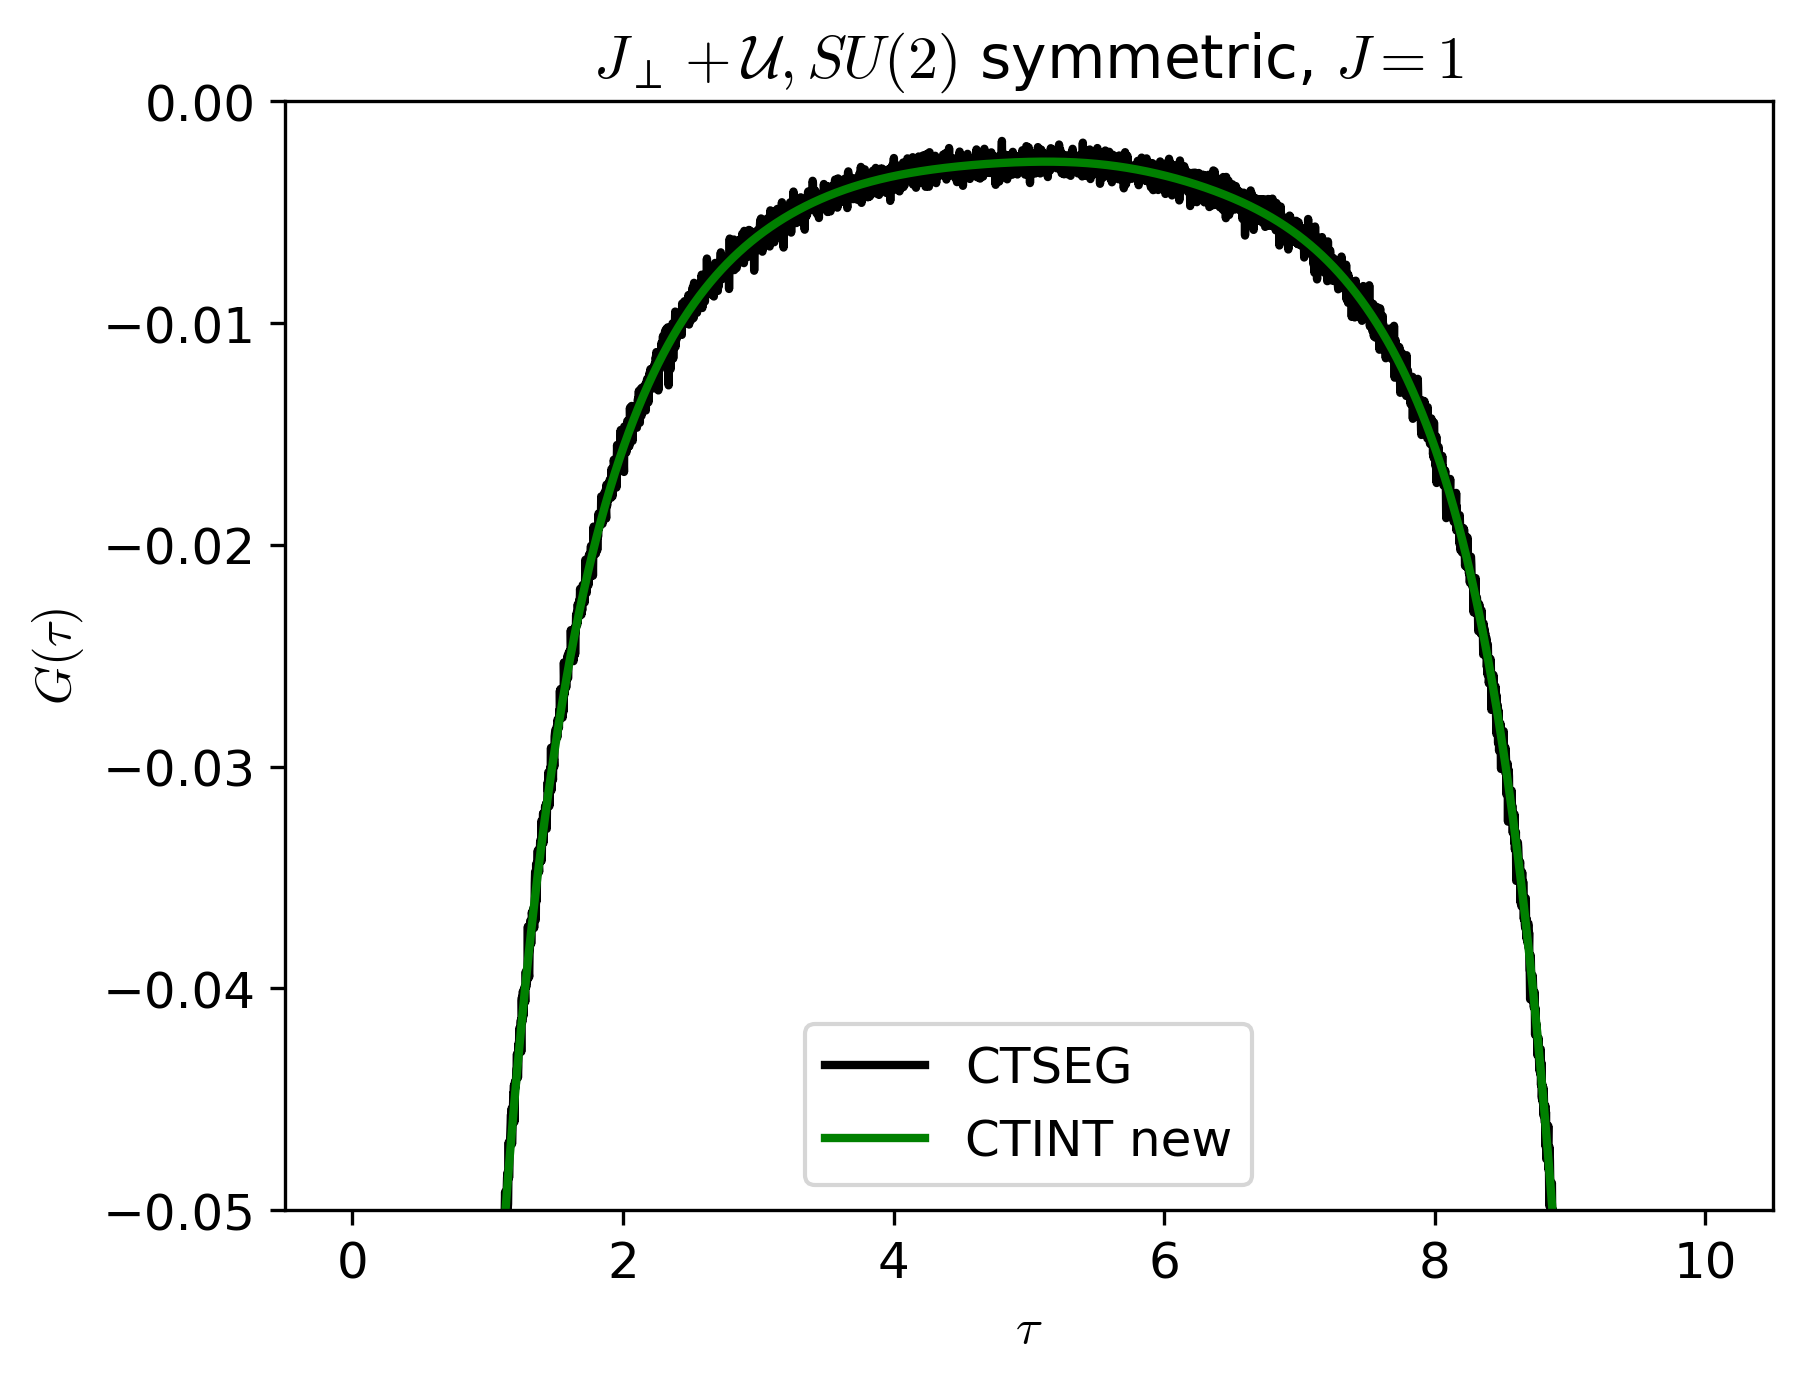

In [43]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
data_ref = "/home/andrewhardy/Documents/CCQ/cthyb_dyn/benchmark/dynamic_int"
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    G_tau_int_1 = A["dmft_loop/i_001/S/G_tau"]
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_seg = A["G_tau"]
    nn = A["nn_tau"]
    nn_iw = A["nn_nu"]
    nn_nu  = make_gf_dlr_imtime(nn_iw)

with HDFArchive(f"{data_loc}/spin_spin_ctint_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_iw_int = A["G_iw"]
    G_tau_int = make_gf_dlr_imtime(G_iw_int)
    G_int_dlr = make_gf_dlr(G_iw_int)
    G_int_tau = make_gf_imtime(G_int_dlr, len(G_tau_seg["up"].data[:,0,0]))
    tau_int = np.array([float(t) for t in G_int_tau.mesh])
    chiAB_tau = A["chiAB_tau"]
    SzSz_int_tau = chiAB_tau#make_gf_dlr_imtime(chiAB_tau)
    #G_int_data = G_int_tau.data[:, 0, 0].real


# with HDFArchive(f"{data_loc}/spin_spin_ctint_old_J-0.5-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
#     print(A.keys())
#     G_iw = A["G_iw"]
#     n_iw = len(G_iw["up"].data)
#     G_tau_int_2 = make_gf_from_fourier(G_iw)
#     nn_ctint = A["chi2ph_tau_from_M3"]
#     nn_ctint_iw = A["chiAB_iw"]
    #nn_ctint = make_gf_from_fourier(nn_ctint_iw)

with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000000_mins-50.h5", "r") as A:
    print(A.keys())
    G_tau_hyb = A["G_tau"]
    print(A["average_sign"], "average sign")
    x = A["perturbation_order"]
    Sz = A["O_tau"]

#oplot(G_tau_hyb["up"].real, color="red", linewidth = 3.5, label="CTHYB")
oplot(G_tau_seg["up"].real, color="black", linewidth = 2.0, label="CTSEG")
oplot(G_int_tau["up"].real, color="green", linewidth = 2.0, label="CTINT new")
plt.title(r"$J_\perp + \mathcal{U}, SU(2)$ symmetric, $J = 1$")
plt.ylabel(r"$G(\tau)$")
plt.ylim(-0.05, 0.0)
plt.legend()
plt.show()

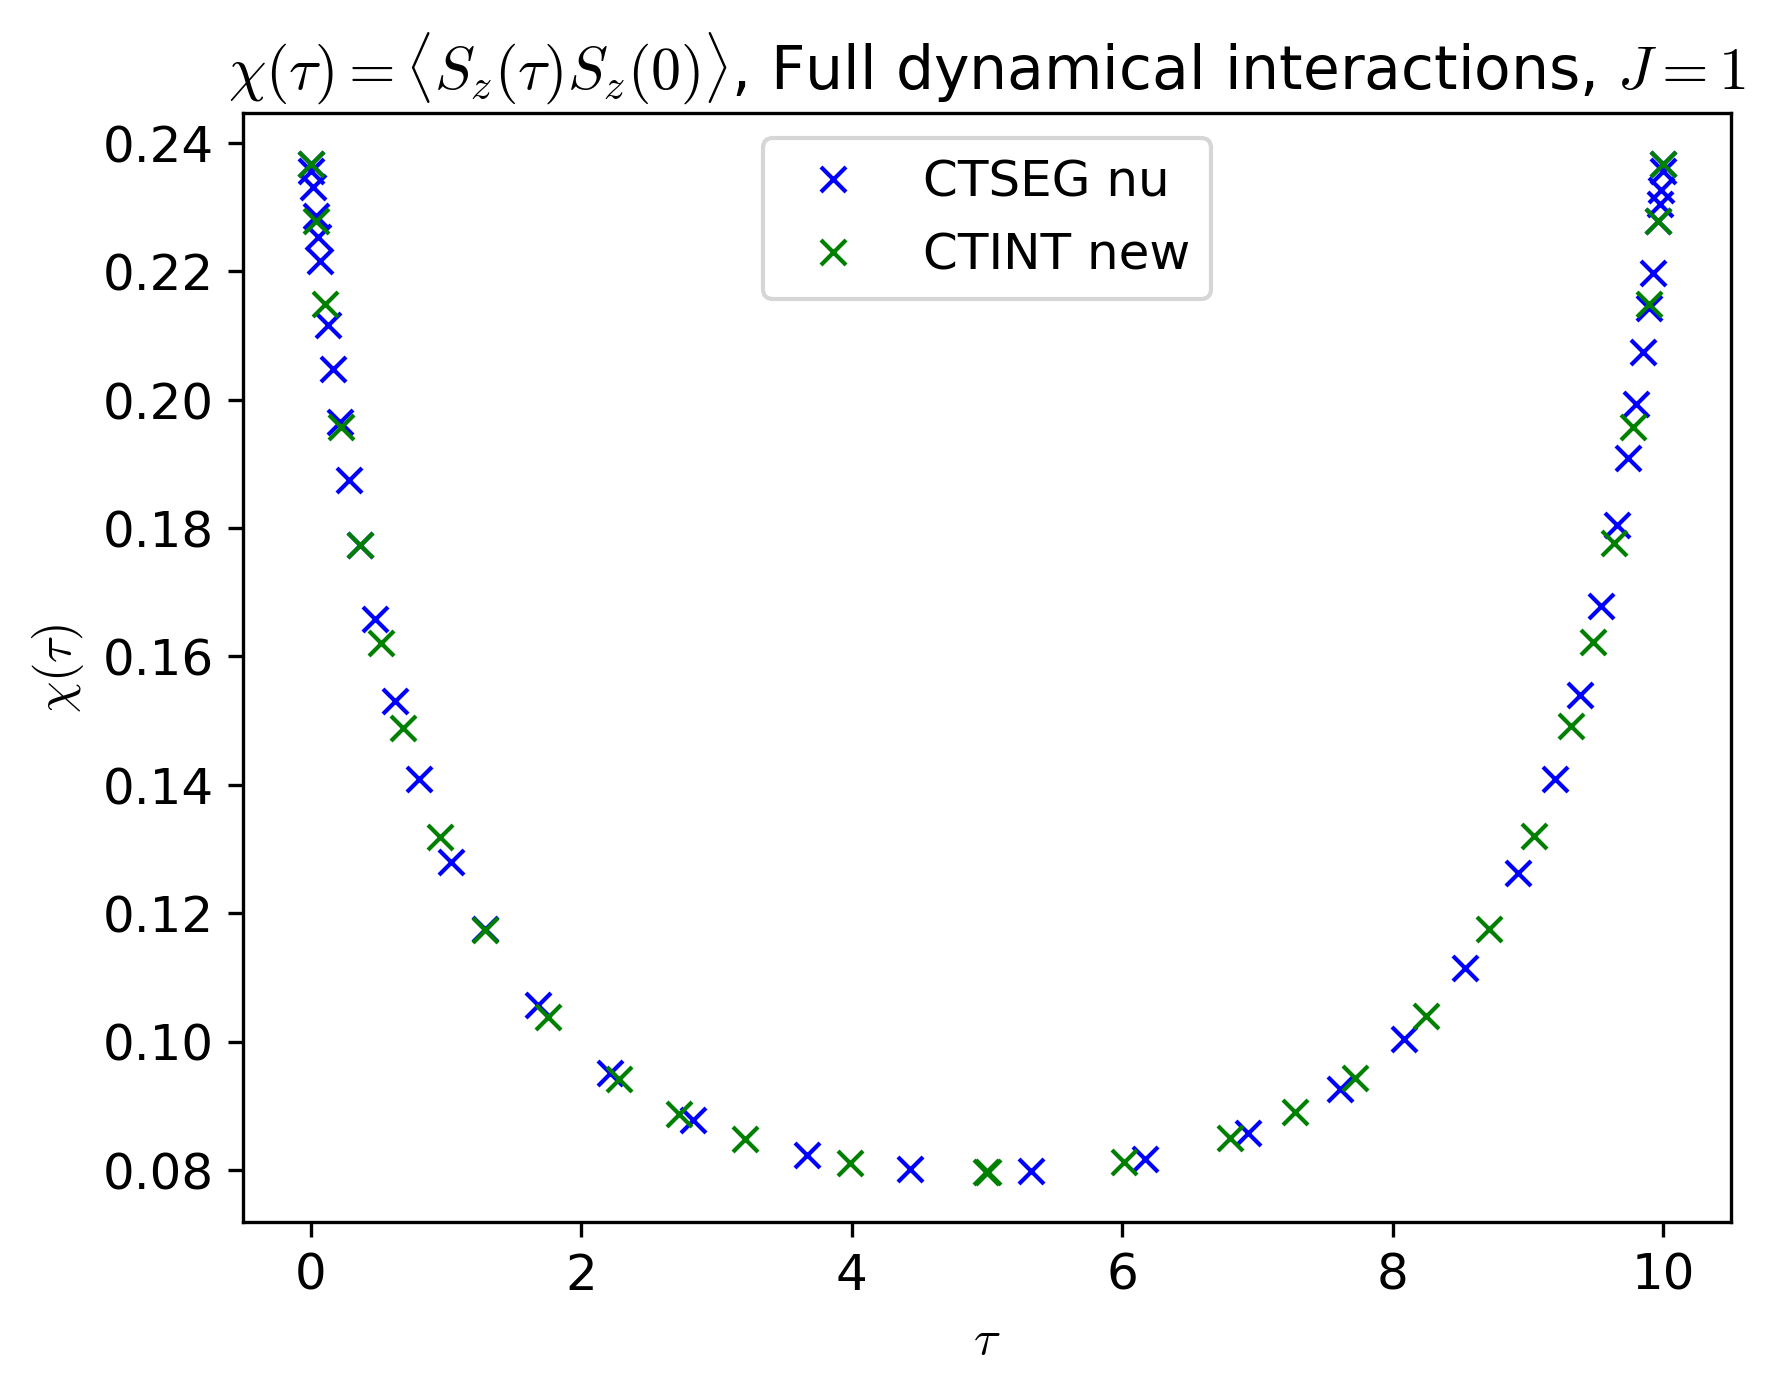

In [51]:
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
Sz_nu = 0.25*(nn_nu["up", "up" ] - nn_nu["up", "down"] - nn_nu["down", "up"] +nn_nu["down", "down"])
Sz_ctint = SzSz_int_tau#1.0*(nn_ctint["up", "up" ] - nn_ctint["up", "dn"] - nn_ctint["dn", "up"] +nn_ctint["dn", "dn"])
Sz_ctint_dlr = make_gf_dlr(Sz_ctint)
Sz_ctint = make_gf_dlr_imtime(Sz_ctint_dlr)
#oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
#oplot(Sz_ctseg.real, color="black", linewidth = 0.9, label="CTSEG")
oplot(Sz_nu.real, color="blue", linewidth = 0.9, label="CTSEG nu")
oplot(Sz_ctint.real, color="green", linewidth = 0.9, label="CTINT new")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$, Full dynamical interactions, $J = 1$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

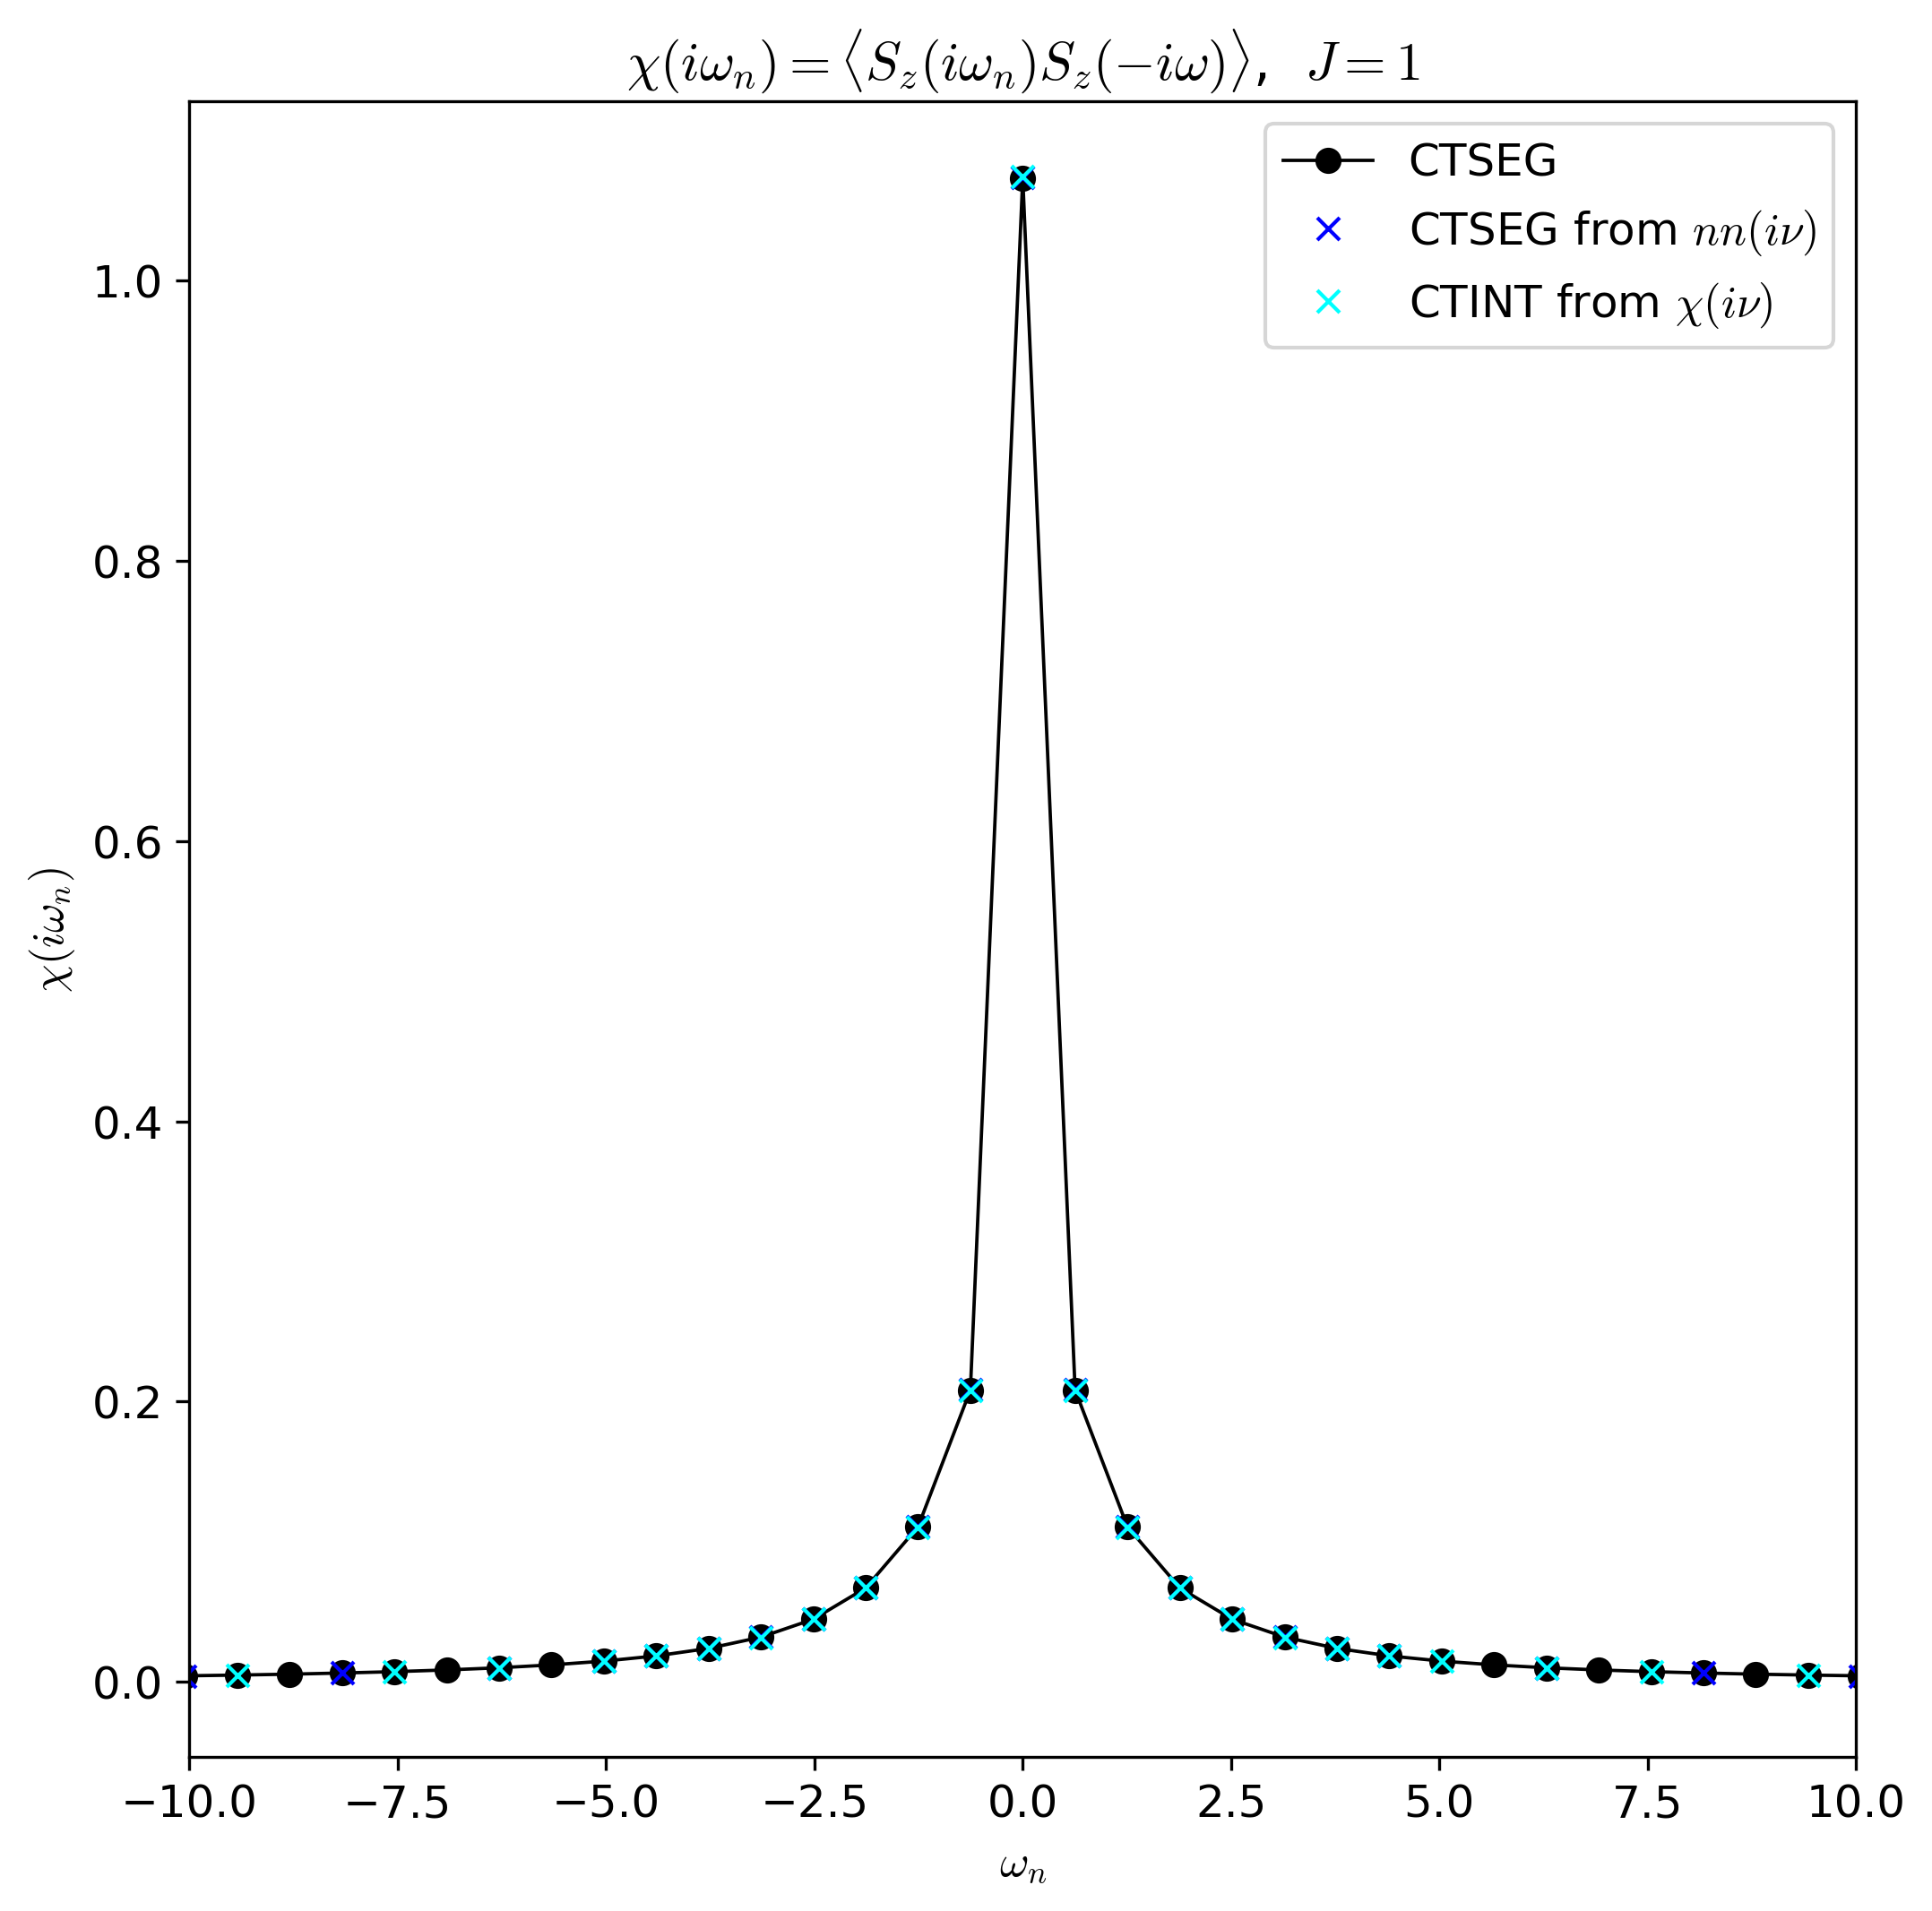

In [54]:
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_nu)
Sz_ctint_fourier = make_gf_dlr_imfreq(Sz_ctint)
plt.figure(figsize=(8,8))
plt.xlim(-10,10)
oplot(Sz_ctseg_fourier.real, "-o",color="black",  linewidth = 0.9, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-o",color="blue",  linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
oplot(Sz_ctint_fourier.real, "-o",color="cyan",  linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(i\omega_n) =\langle S_z(i\omega_n) S_z(-i\omega) \rangle$,  $J = 1$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(d, color="blue", label="D perturbation order")
plt.plot(j, color="orange", label="J perturbation order")
plt.title("Perturbation order distribution")
plt.xlabel("Monte Carlo step")
plt.ylabel("Perturbation order")
plt.legend()
plt.show()

NameError: name 'd' is not defined

<Figure size 1200x1200 with 0 Axes>

### CTSEG compared to CTHYB for generalized susceptibilities, full dynamic interactions

['G_tau', 'nn_tau']
['G_tau', 'O_tau', 'average_sign', 'perturbation_order']
1.0 average sign


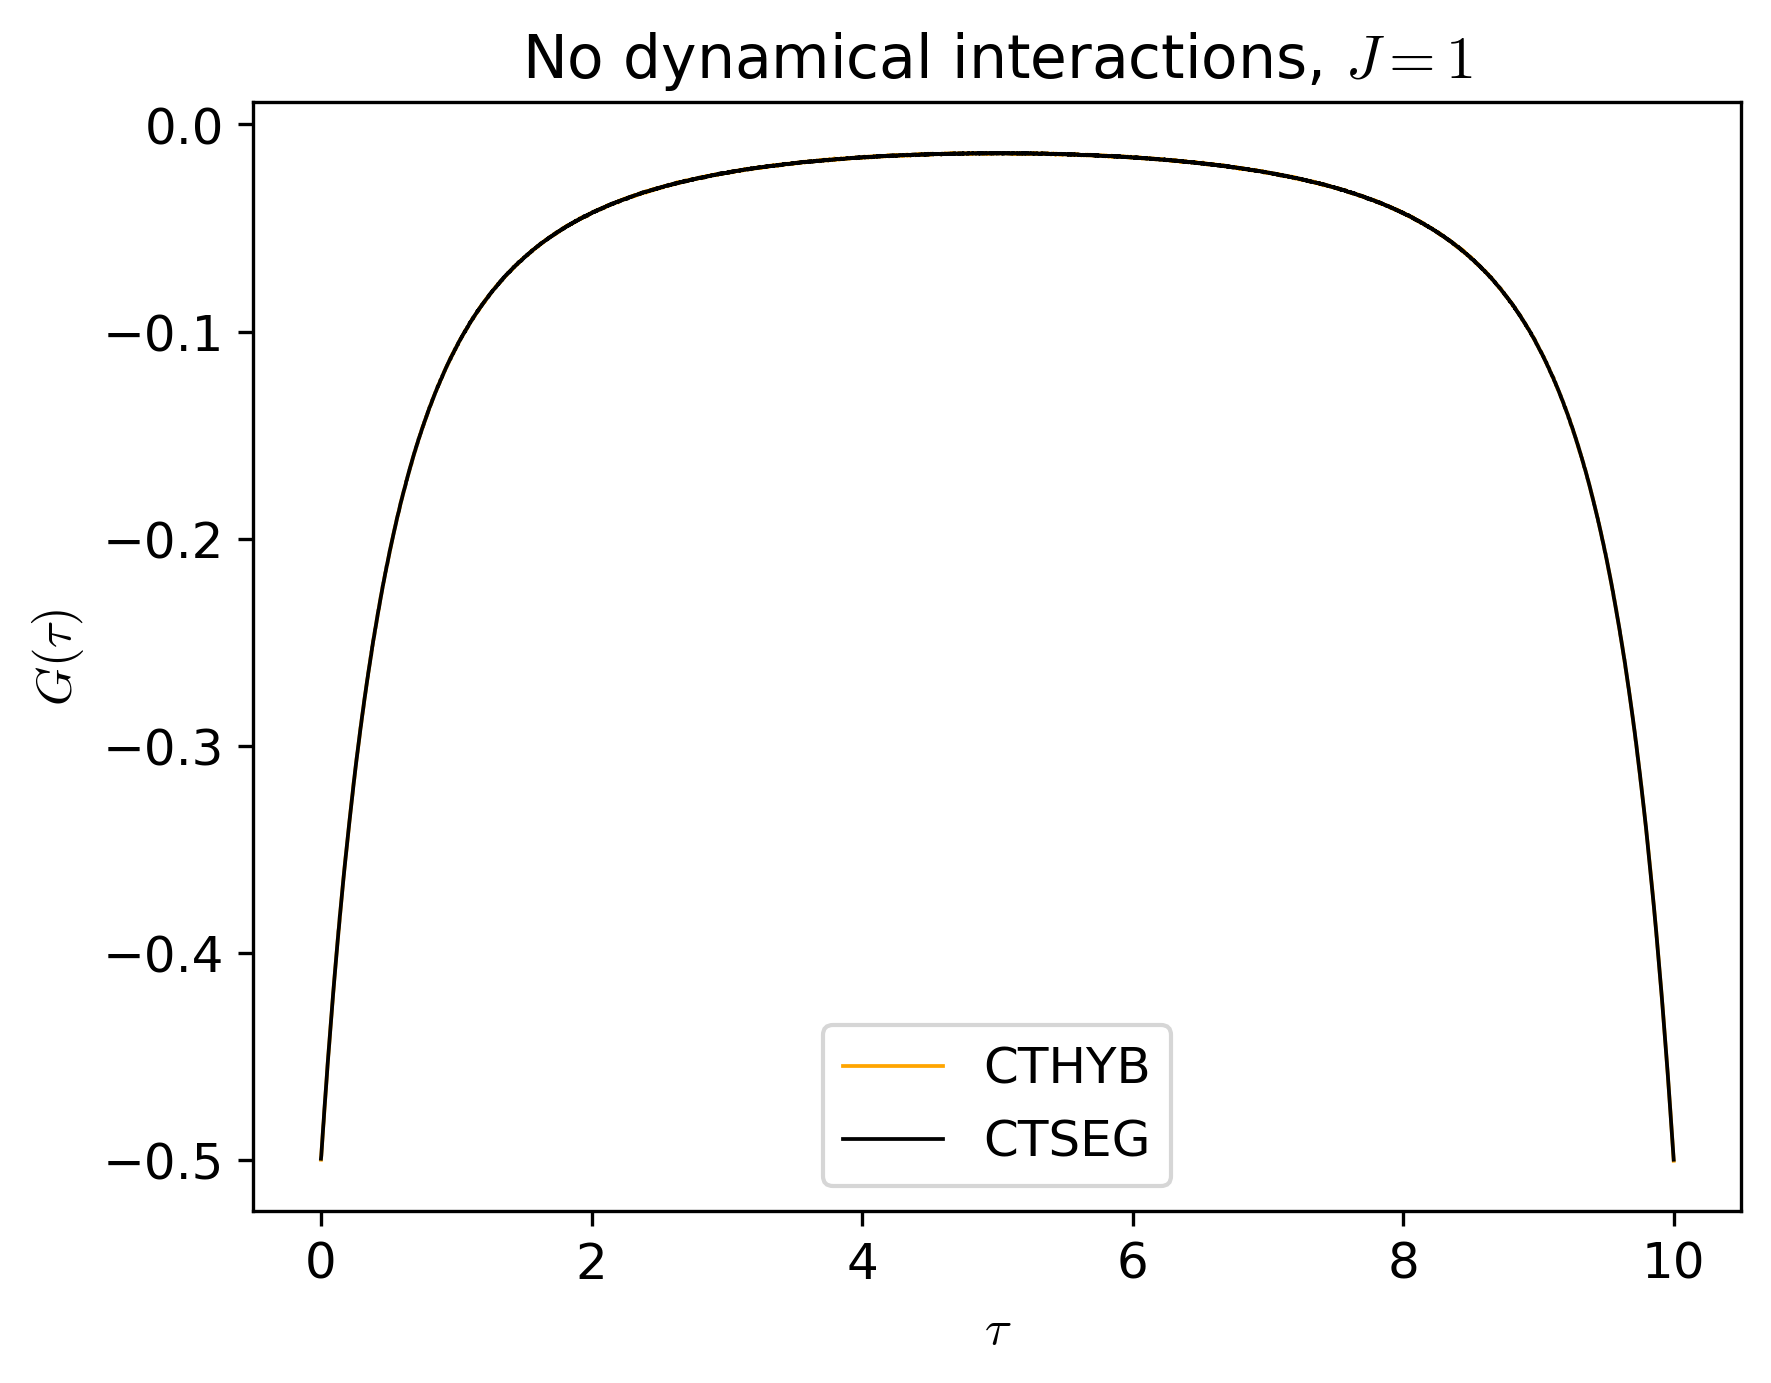

In [ ]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
data_ref = "/home/andrewhardy/Documents/CCQ/cthyb_dyn/benchmark/dynamic_int"
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    G_tau_int = A["dmft_loop/i_001/S/G_tau"]

with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_0.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_seg = A["G_tau"]
    #d = A["perturbation_order_D"]
    #j = A["perturbation_order_J"]
    nn = A["nn_tau"]
with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0-U-4.0_0.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_hyb = A["G_tau"]
    print(A["average_sign"], "average sign")
    Sz = A["O_tau"]

oplot(G_tau_hyb["up"].real, color="orange", linewidth = 0.9, label="CTHYB")
oplot(G_tau_seg["up"].real, color="black", linewidth = 0.9, label="CTSEG")
plt.title(r"No dynamical interactions, $J = 1$")
plt.ylabel(r"$G(\tau)$")
plt.legend()
plt.show()

### CTSEG compared to CTHYB for generalized susceptibilities, no dynamical interactions

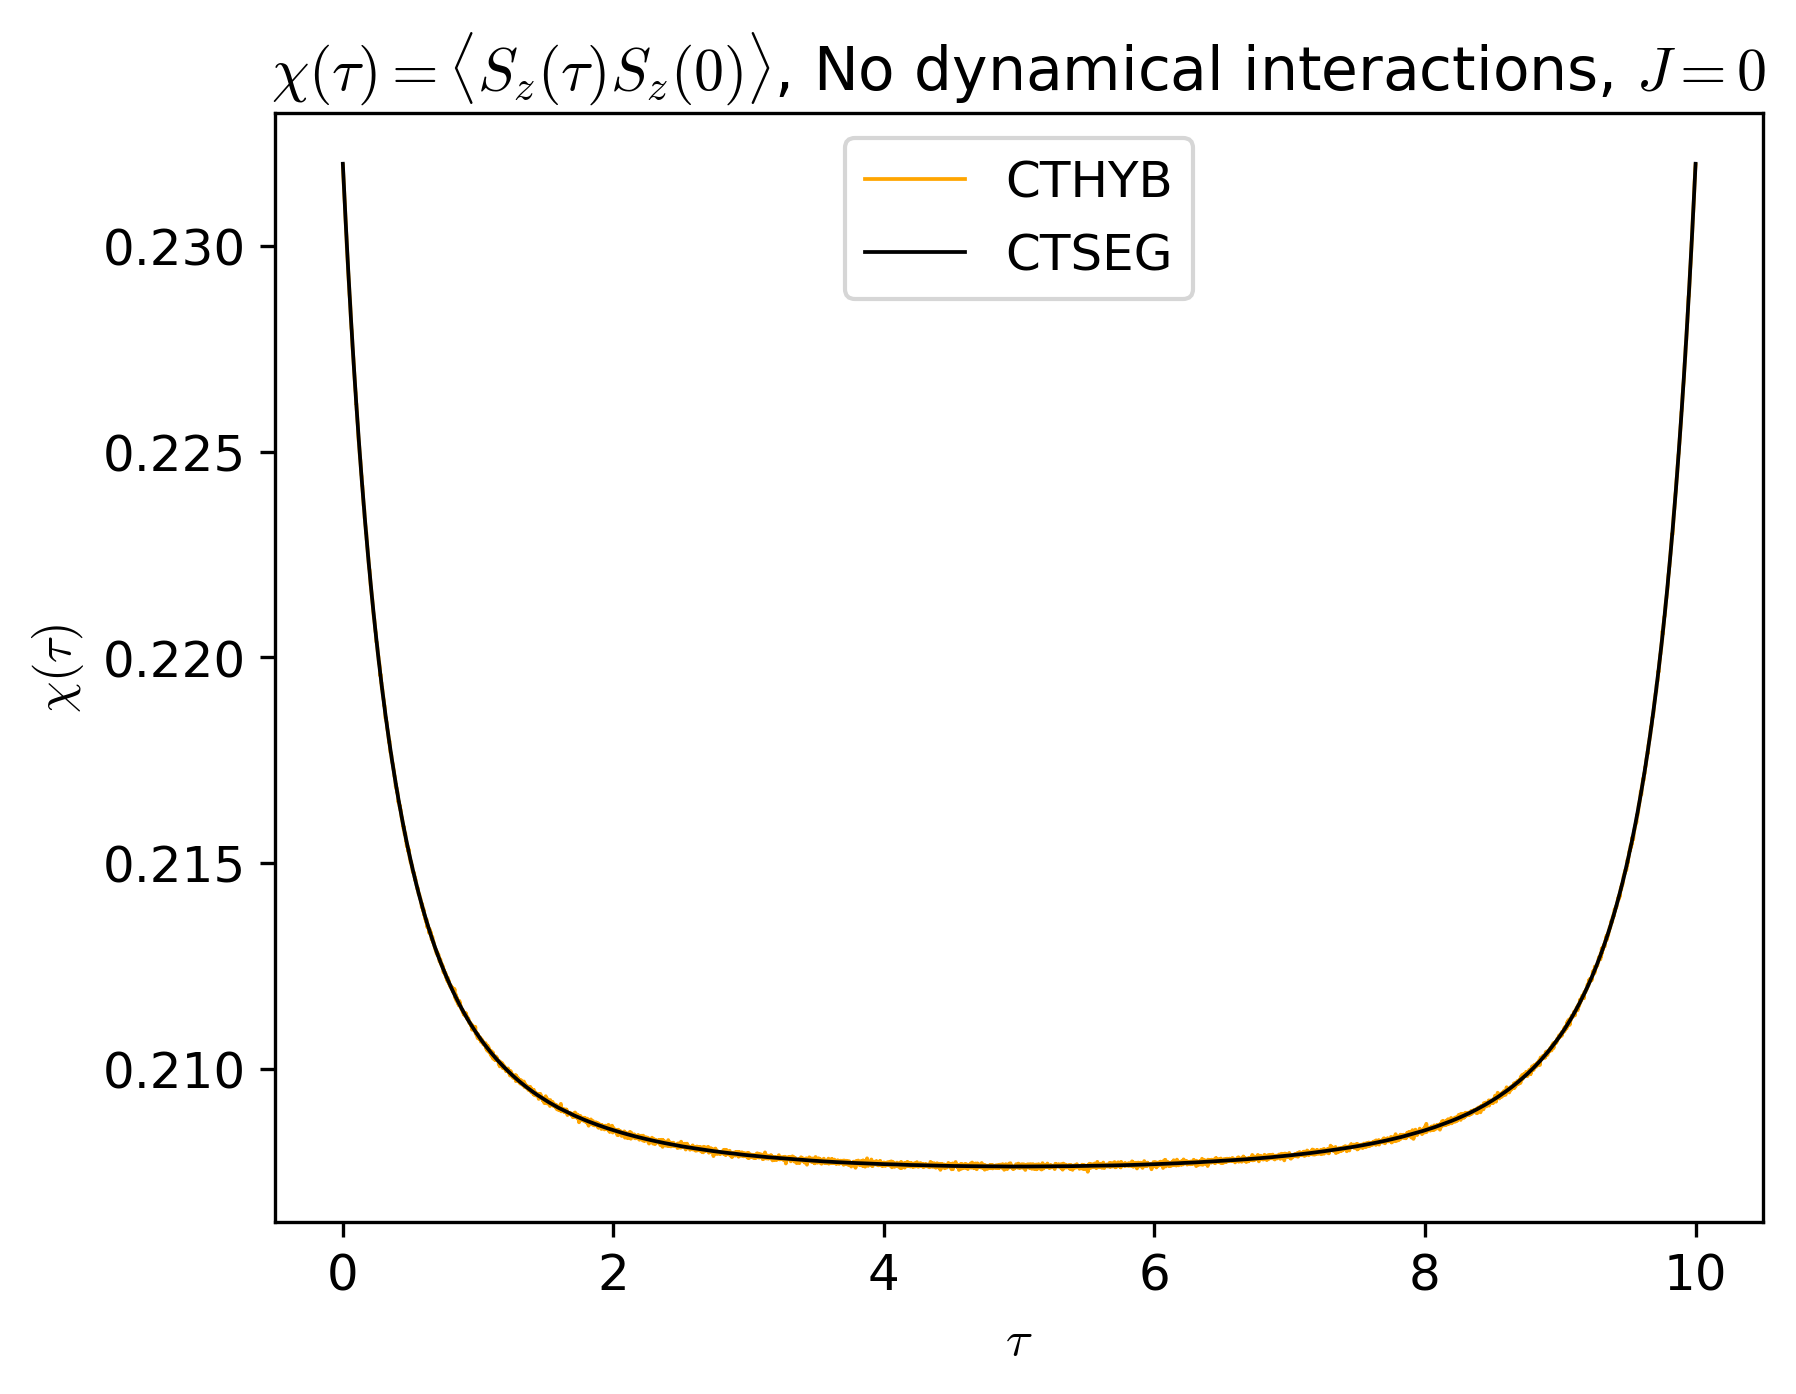

In [ ]:
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg.real, color="black", linewidth = 0.9, label="CTSEG")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$, No dynamical interactions, $J = 0$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

### CTSEG compared to CTHYB for generalized susceptibilities, only $J_\perp$ dynamical interactions

In [ ]:
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    print(A.keys())
    print(A["dmft_loop/i_001/S/nn_tau"])

['dmft_loop', 'input']
Green Function nn_tau composed of 4 blocks: 
 Green's Function nn_tau_up|up with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 2001 and target_shape (1, 1): 
 
 Green's Function nn_tau_up|dn with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 2001 and target_shape (1, 1): 
 
 Green's Function nn_tau_dn|up with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 2001 and target_shape (1, 1): 
 
 Green's Function nn_tau_dn|dn with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 2001 and target_shape (1, 1): 
 



['G_tau', 'average_sign', 'densities', 'nn', 'nn_nu', 'nn_tau', 'perturbation_order_D', 'perturbation_order_J']
['G0_iw', 'G2_iw', 'G_iw', 'chi2ph_iw', 'chi2ph_tau_from_M3', 'chi2pp_iw', 'chi2pp_tau_from_M3', 'chi2xph_tau_from_M3', 'chi3ph_iw', 'chi3pp_iw', 'chi3xph_iw', 'chiAB_iw']
['G0_iw', 'G2_iw', 'G_iw', 'chi2ph_iw', 'chi2ph_tau_from_M3', 'chi2pp_iw', 'chi2pp_tau_from_M3', 'chi2xph_tau_from_M3', 'chi3ph_iw', 'chi3pp_iw', 'chi3xph_iw', 'chiAB_iw']
['G_tau', 'O_tau', 'average_sign', 'perturbation_order']
1.0 average sign


/home/andrewhardy/Documents/CCQ/installation/lib/python3.12/site-packages/h5/archive.py:232: UserWarning: The hdf5 format Histogram is not recognized. Returning as a group. Did you forgot to import this python class ?
  warnings.warn(f"The hdf5 format {hdf5_format} is not recognized. Returning as a group. Did you forgot to import this python class ?")


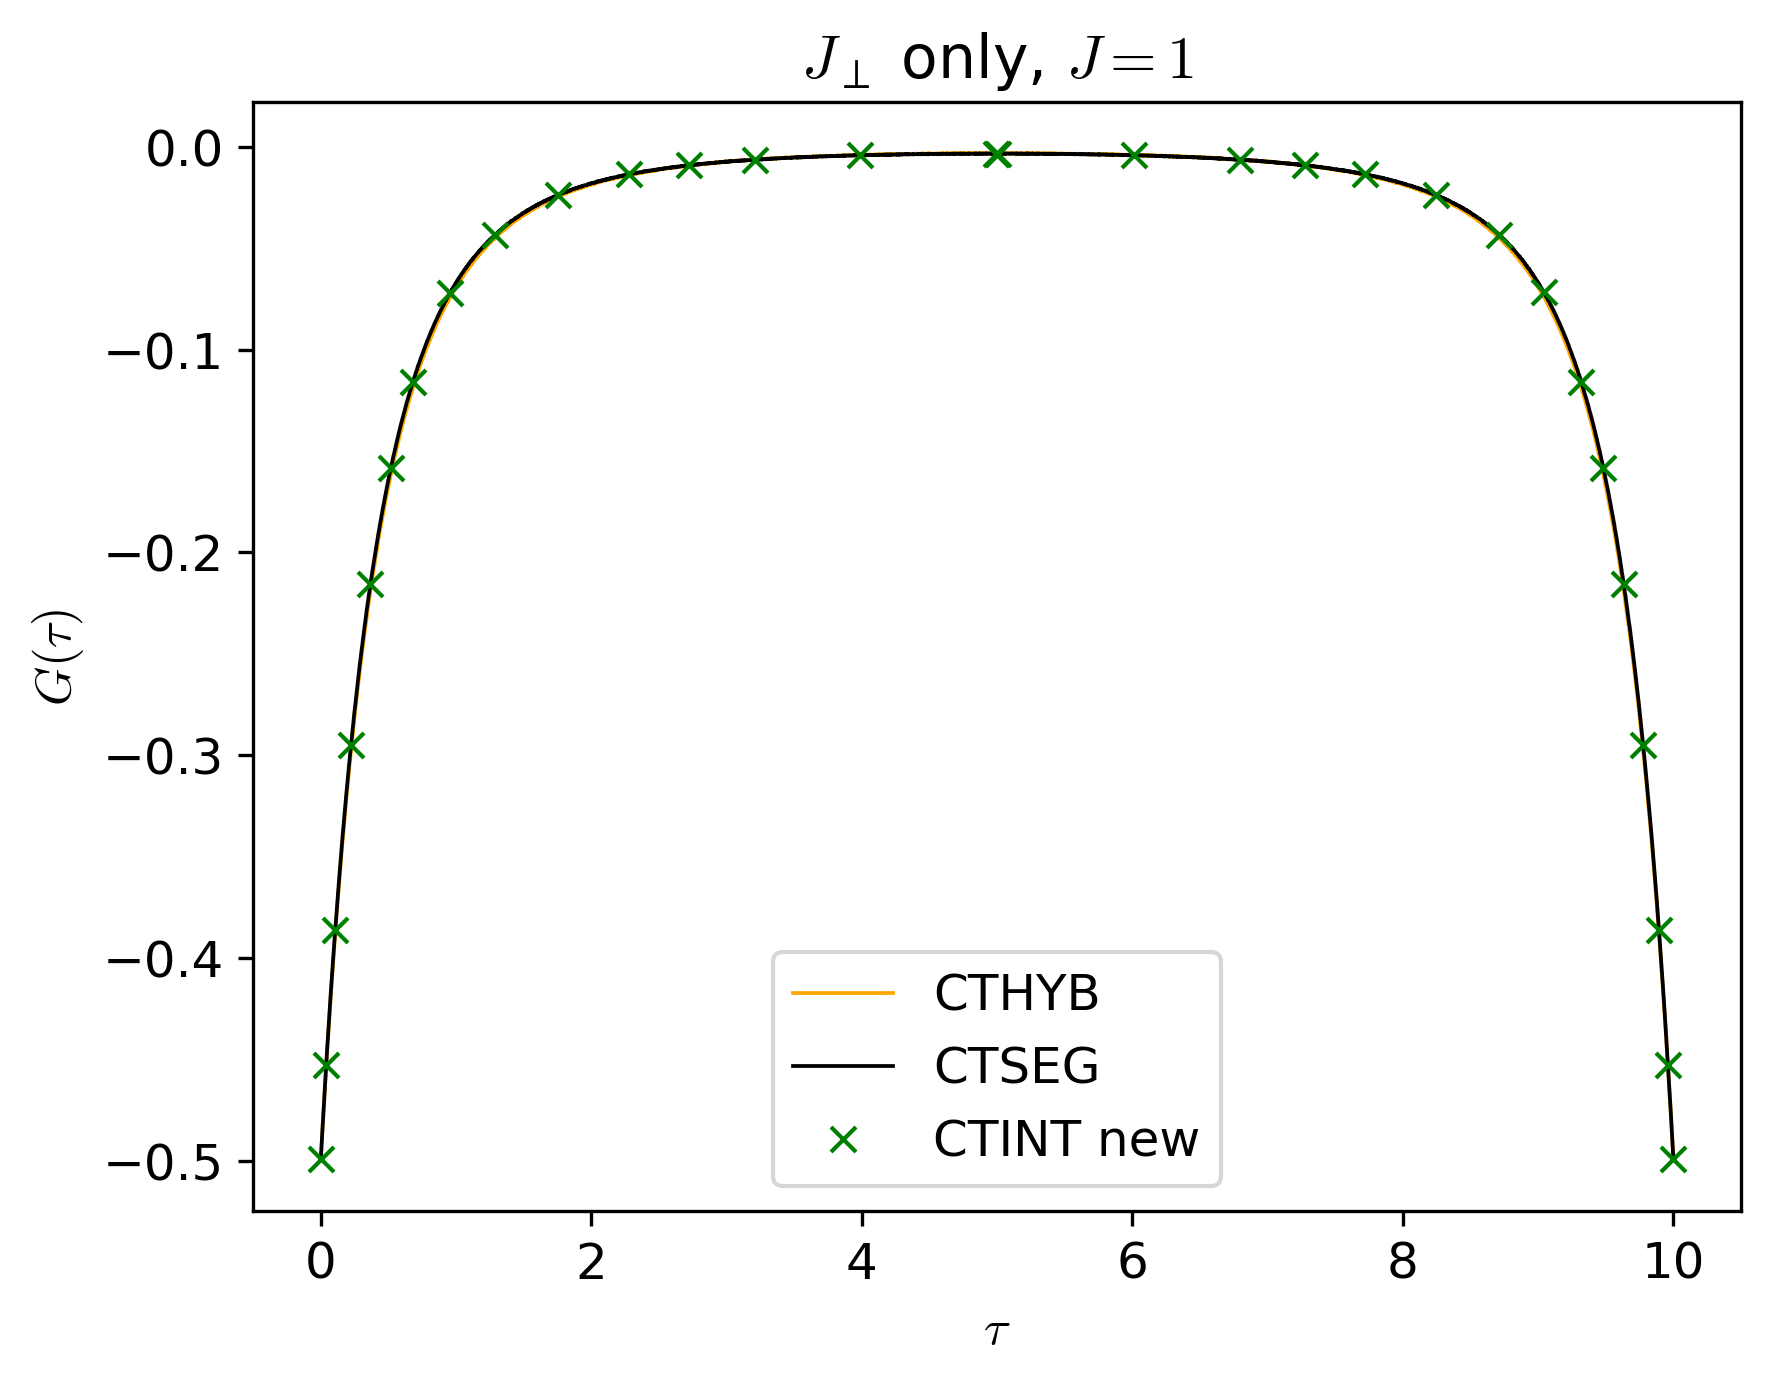

In [ ]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
data_ref = "/home/andrewhardy/Documents/CCQ/cthyb_dyn/benchmark/dynamic_int"
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    G_tau_int_1 = A["dmft_loop/i_001/S/G_tau"]
    nn_tau_ref = A["dmft_loop/i_001/S/nn_tau"]
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_seg = A["G_tau"]
    #d = A["perturbation_order_D"]
    #j = A["perturbation_order_J"]
    nn = A["nn_tau"]
    nn_iw = A["nn_nu"]
    nn_nu  = make_gf_dlr_imtime(nn_iw)

with HDFArchive(f"{data_loc}/spin_spin_ctint_old_J-0.5-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_iw = A["G_iw"]
    G_tau_int_2 = make_gf_from_fourier(G_iw)
    #G_tau_int = make_gf_dlr_imtime(G_iw)
    #print(A["average_sign"], "average sign")
    #x = A["perturbation_order"]
    #Sz = A["O_tau"]
    nn_ctint = A["chi2ph_tau_from_M3"]
    nn_ctint_iw = A["chiAB_iw"]
    #nn_ctint = make_gf_from_fourier(nn_ctint_iw)
with HDFArchive(f"{data_loc}/spin_spin_ctint_J-0.5-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_iw = A["G_iw"]
    n_iw = len(G_iw["up"].data)
    G_tau_int_2 = make_gf_dlr_imtime(G_iw)
    #print(G_iw)
    #G_tau_int_2 = GfImTime(indices=[0], beta=10.0, n_points=n_iw*2-1)
    #print(G_tau_int_2)
    #G_tau_int_2 << Fourier(G_iw) 
    #G_tau_int = make_gf_dlr_imtime(G_iw)
    #print(A["average_sign"], "average sign")
    #x = A["perturbation_order"]
    #Sz = A["O_tau"]
    nn_ctint = A["chi2ph_tau_from_M3"]
    nn_ctint_iw = A["chi2ph_iw"]
    #nn_ctint = make_gf_from_fourier(nn_ctint_iw)

with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_hyb = A["G_tau"]
    print(A["average_sign"], "average sign")
    x = A["perturbation_order"]
    Sz = A["O_tau"]

oplot(G_tau_hyb["up"].real, color="orange", linewidth = 0.9, label="CTHYB")
oplot(G_tau_seg["up"].real, color="black", linewidth = 0.9, label="CTSEG")
#oplot(G_tau_int_1["up"].real, color="blue", linewidth = 0.9, label="CTINT old")
oplot(G_tau_int_2["up"].real, color="green", linewidth = 0.9, label="CTINT new")
plt.title(r"$J_\perp$ only, $J = 1$")
plt.ylabel(r"$G(\tau)$")
plt.legend()
plt.show()

In [ ]:
nn_ctint

Green's Function chi2ph_tau_from_M3 composed of 4 2-index blocks: 
 Green's Function chi2ph_tau_from_M3_('down', 'down') with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 81 and target_shape (1, 1, 1, 1): 
 
 Green's Function chi2ph_tau_from_M3_('down', 'up') with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 81 and target_shape (1, 1, 1, 1): 
 
 Green's Function chi2ph_tau_from_M3_('up', 'down') with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 81 and target_shape (1, 1, 1, 1): 
 
 Green's Function chi2ph_tau_from_M3_('up', 'up') with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 81 and target_shape (1, 1, 1, 1): 
 

In [ ]:
nn_tau_ref['up|dn']

Green's Function nn_tau_up|dn with mesh Imaginary time mesh with beta = 10, statistics = Boson, N = 2001 and target_shape (1, 1): 

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_153346/1284248798.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$,"+"$J_\perp$ only, $J = 1$")


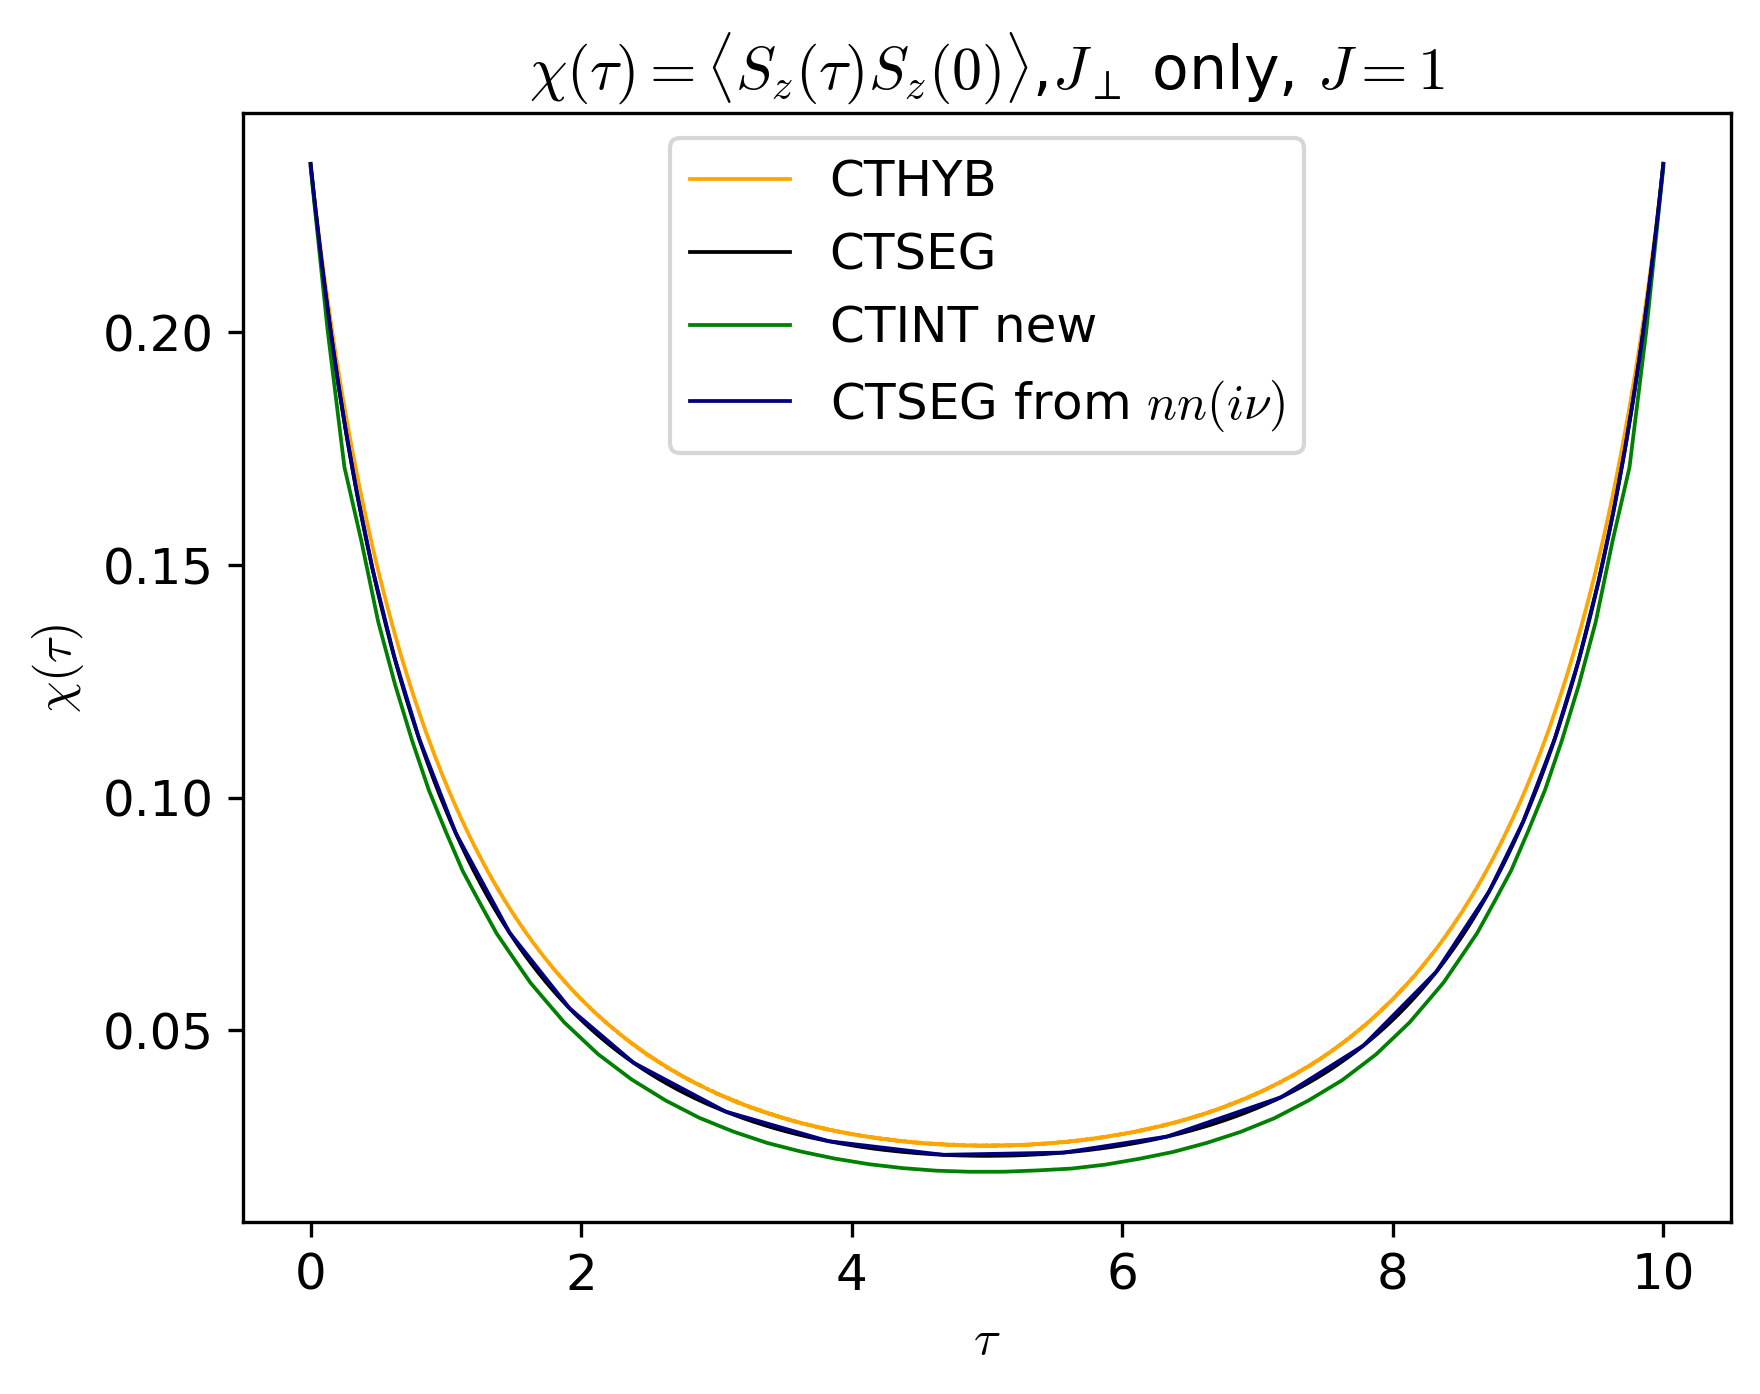

In [ ]:
#Sz_ref = 0.25*(nn_tau_ref['up|up'] - nn_tau_ref['up|dn'] - nn_tau_ref["dn|up"] +nn_tau_ref['dn|dn'])
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
Sz_ctint = 0.25*(nn_ctint["up", "up" ] - nn_ctint["up", "down"] - nn_ctint["down", "up"] +nn_ctint["down", "down"])
Sz_ctseg_nu = 0.25*(nn_nu["up", "up" ] - nn_nu["up", "down"] - nn_nu["down", "up"] +nn_nu["down", "down"])
tau = np.array([x.real for x in Sz_ctseg_nu.mesh.values()])
#oplot(Sz_ref.real, color="blue", linewidth = 0.9, label="CTINT old")
oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg.real,  color="black", linewidth = 0.9, label="CTSEG")
oplot(Sz_ctint.real, color="green", linewidth = 0.9, label="CTINT new")
plt.plot(tau,Sz_ctseg_nu.real.data[:,0,0],"-", color="navy", linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$,"+"$J_\perp$ only, $J = 1$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

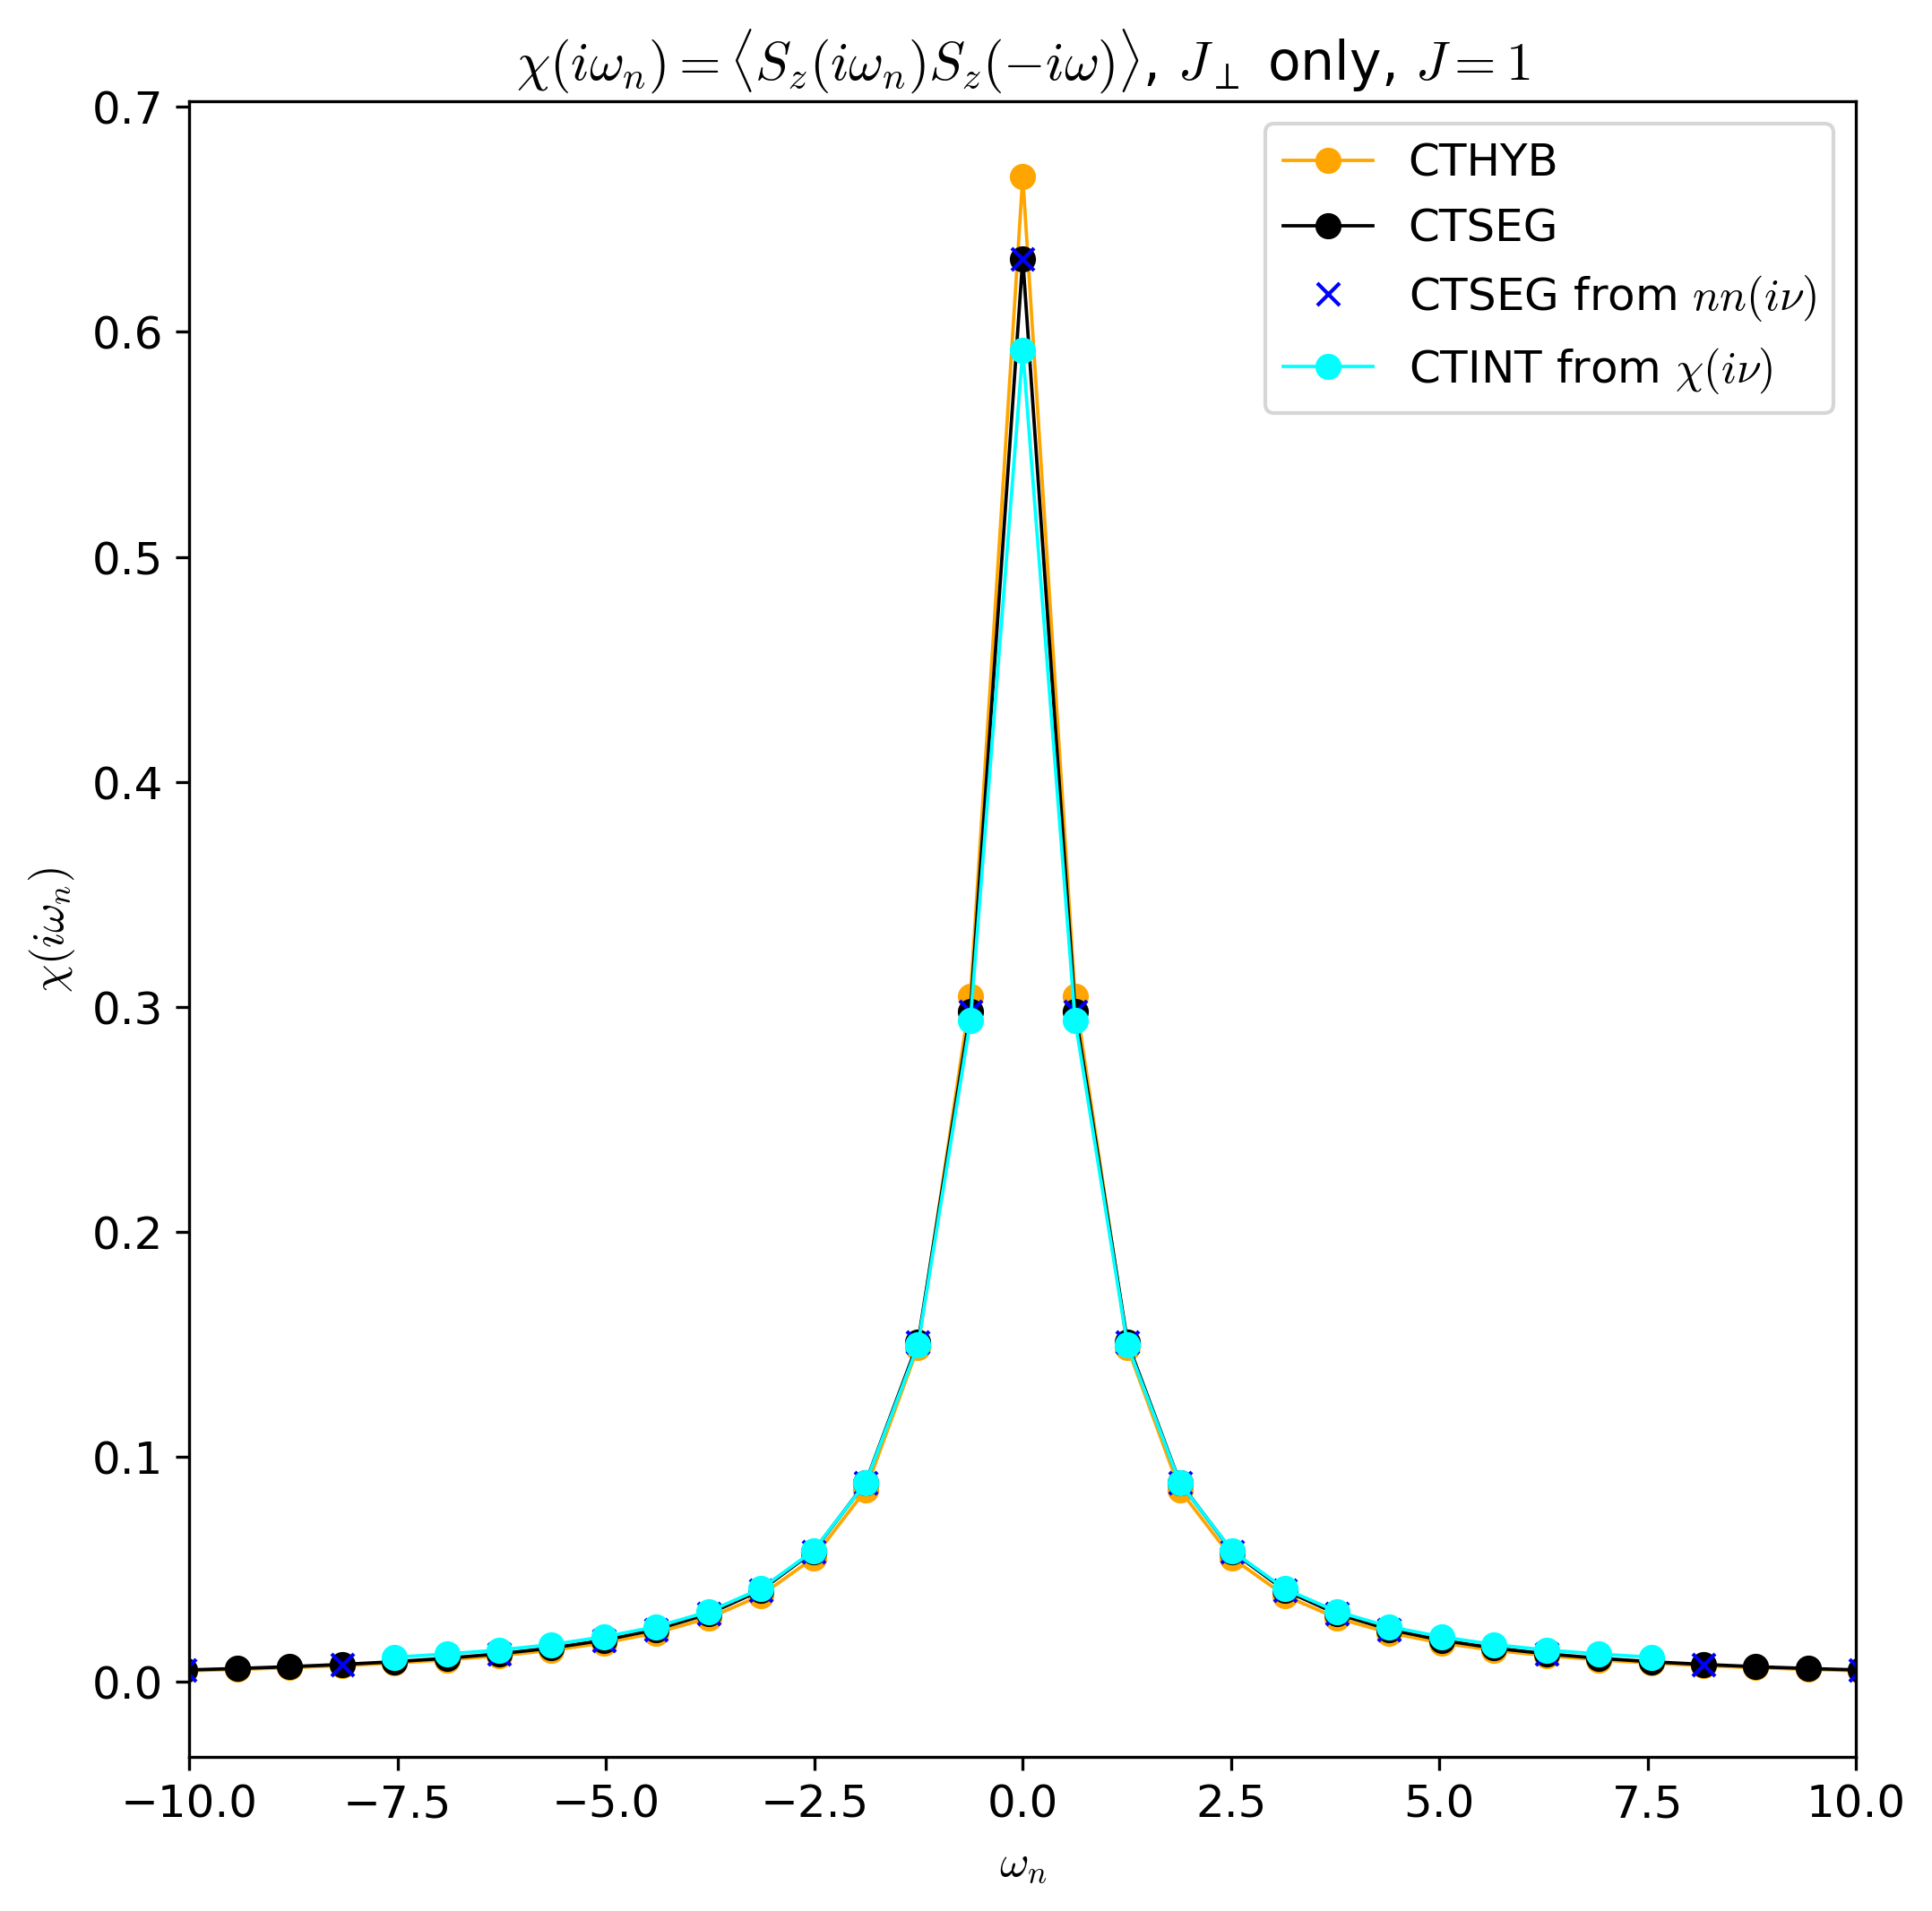

In [ ]:
Sz_fourier = make_gf_from_fourier(Sz)
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_ctseg_nu)
Sz_ctint_fourier = make_gf_from_fourier(Sz_ctint)
plt.figure(figsize=(8,8))
plt.xlim(-10,10)
oplot(Sz_fourier.real,"-o", color="orange", linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg_fourier.real, "-o",color="black",  linewidth = 0.9, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-o",color="blue",  linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
oplot(Sz_ctint_fourier.real, "-o",color="cyan",  linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(i\omega_n) =\langle S_z(i\omega_n) S_z(-i\omega) \rangle$, $J_\perp$ only, $J = 1$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend()
plt.show()

In [ ]:
print(x)

{'down': array([4.72602674e+08, 5.75810905e+08, 3.51744151e+08, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00]), 'up': array([4.72577674e+08, 5.75788947e+08, 3.51740159e+08, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])}


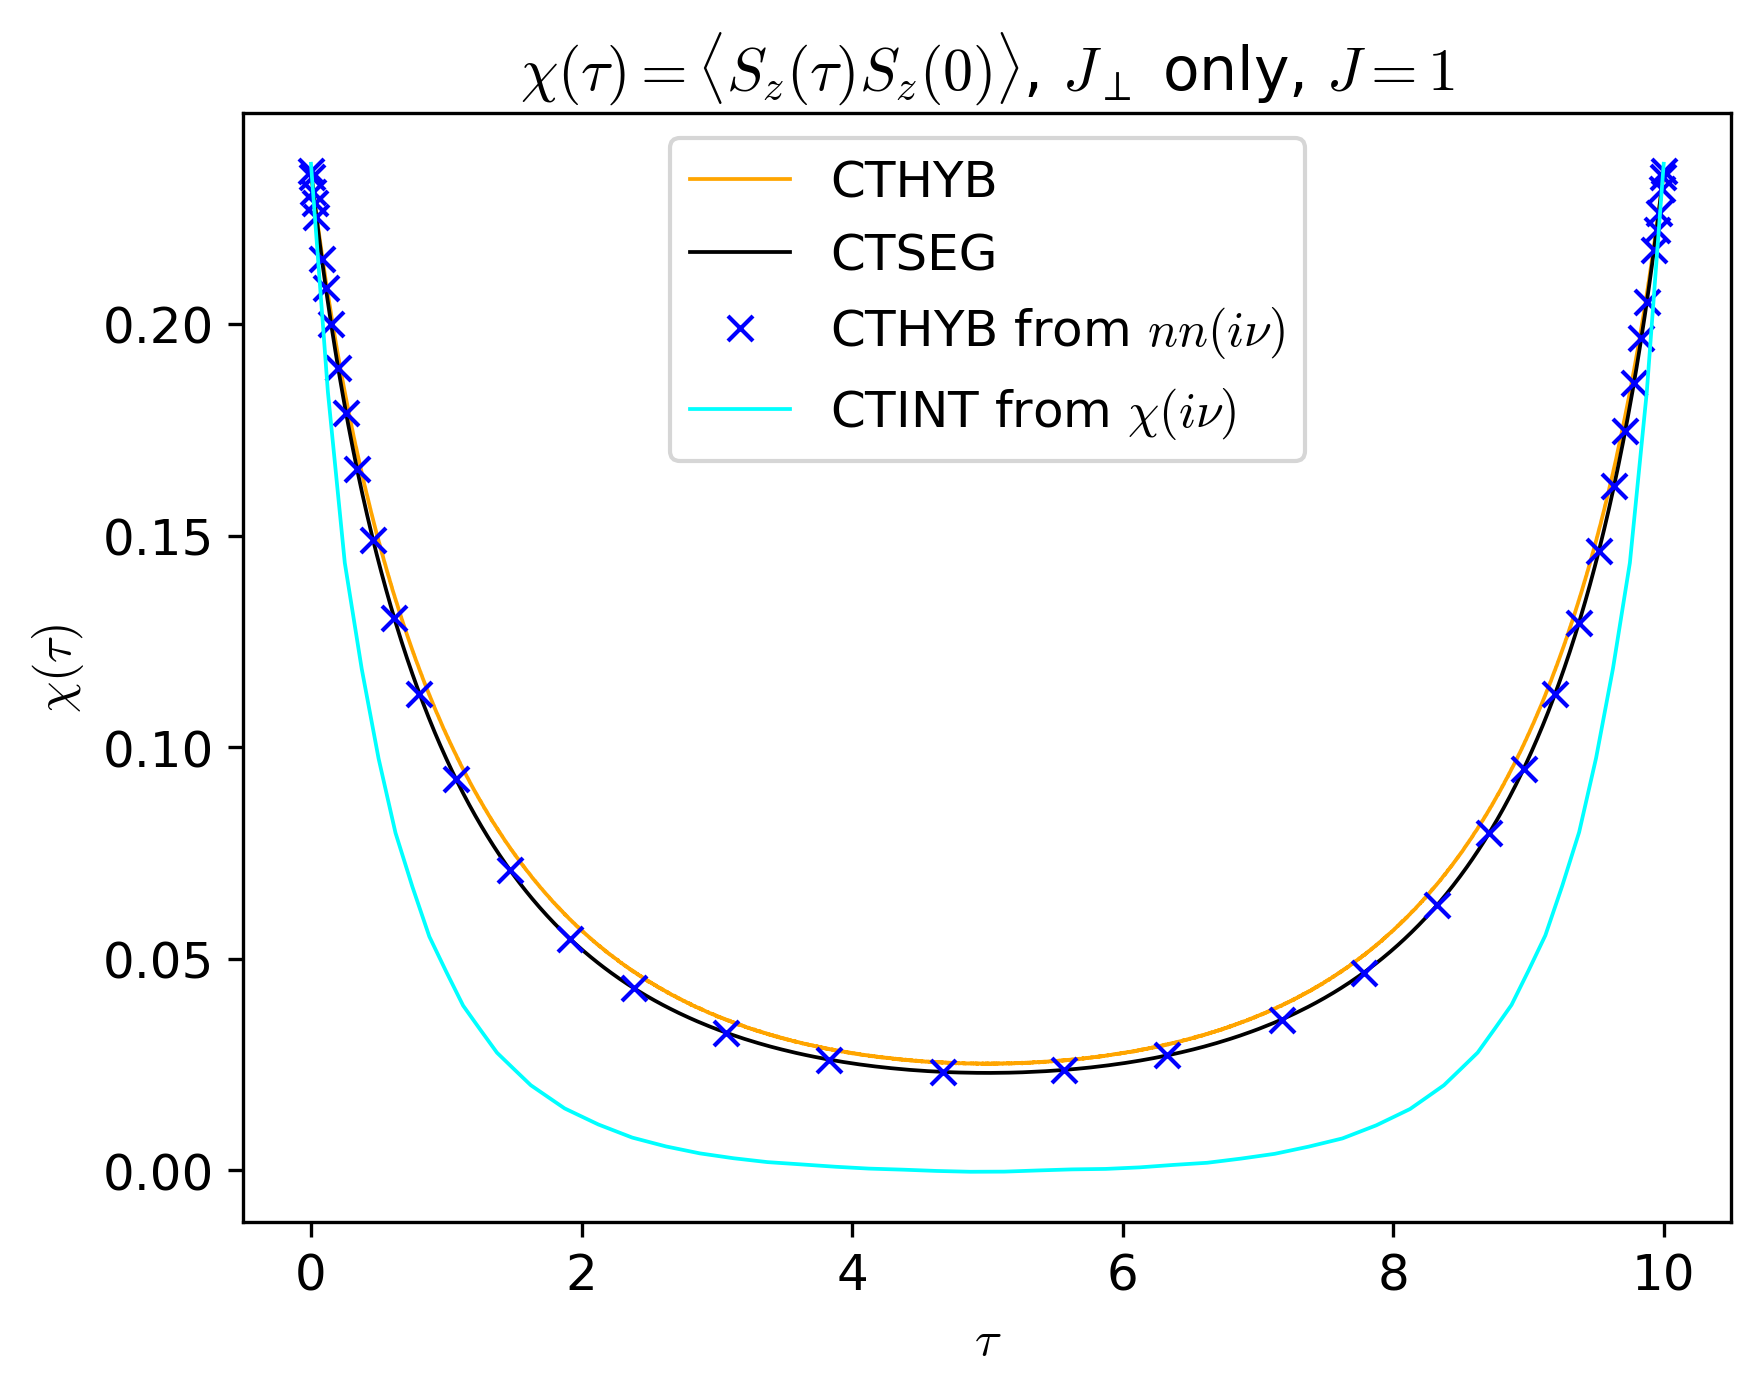

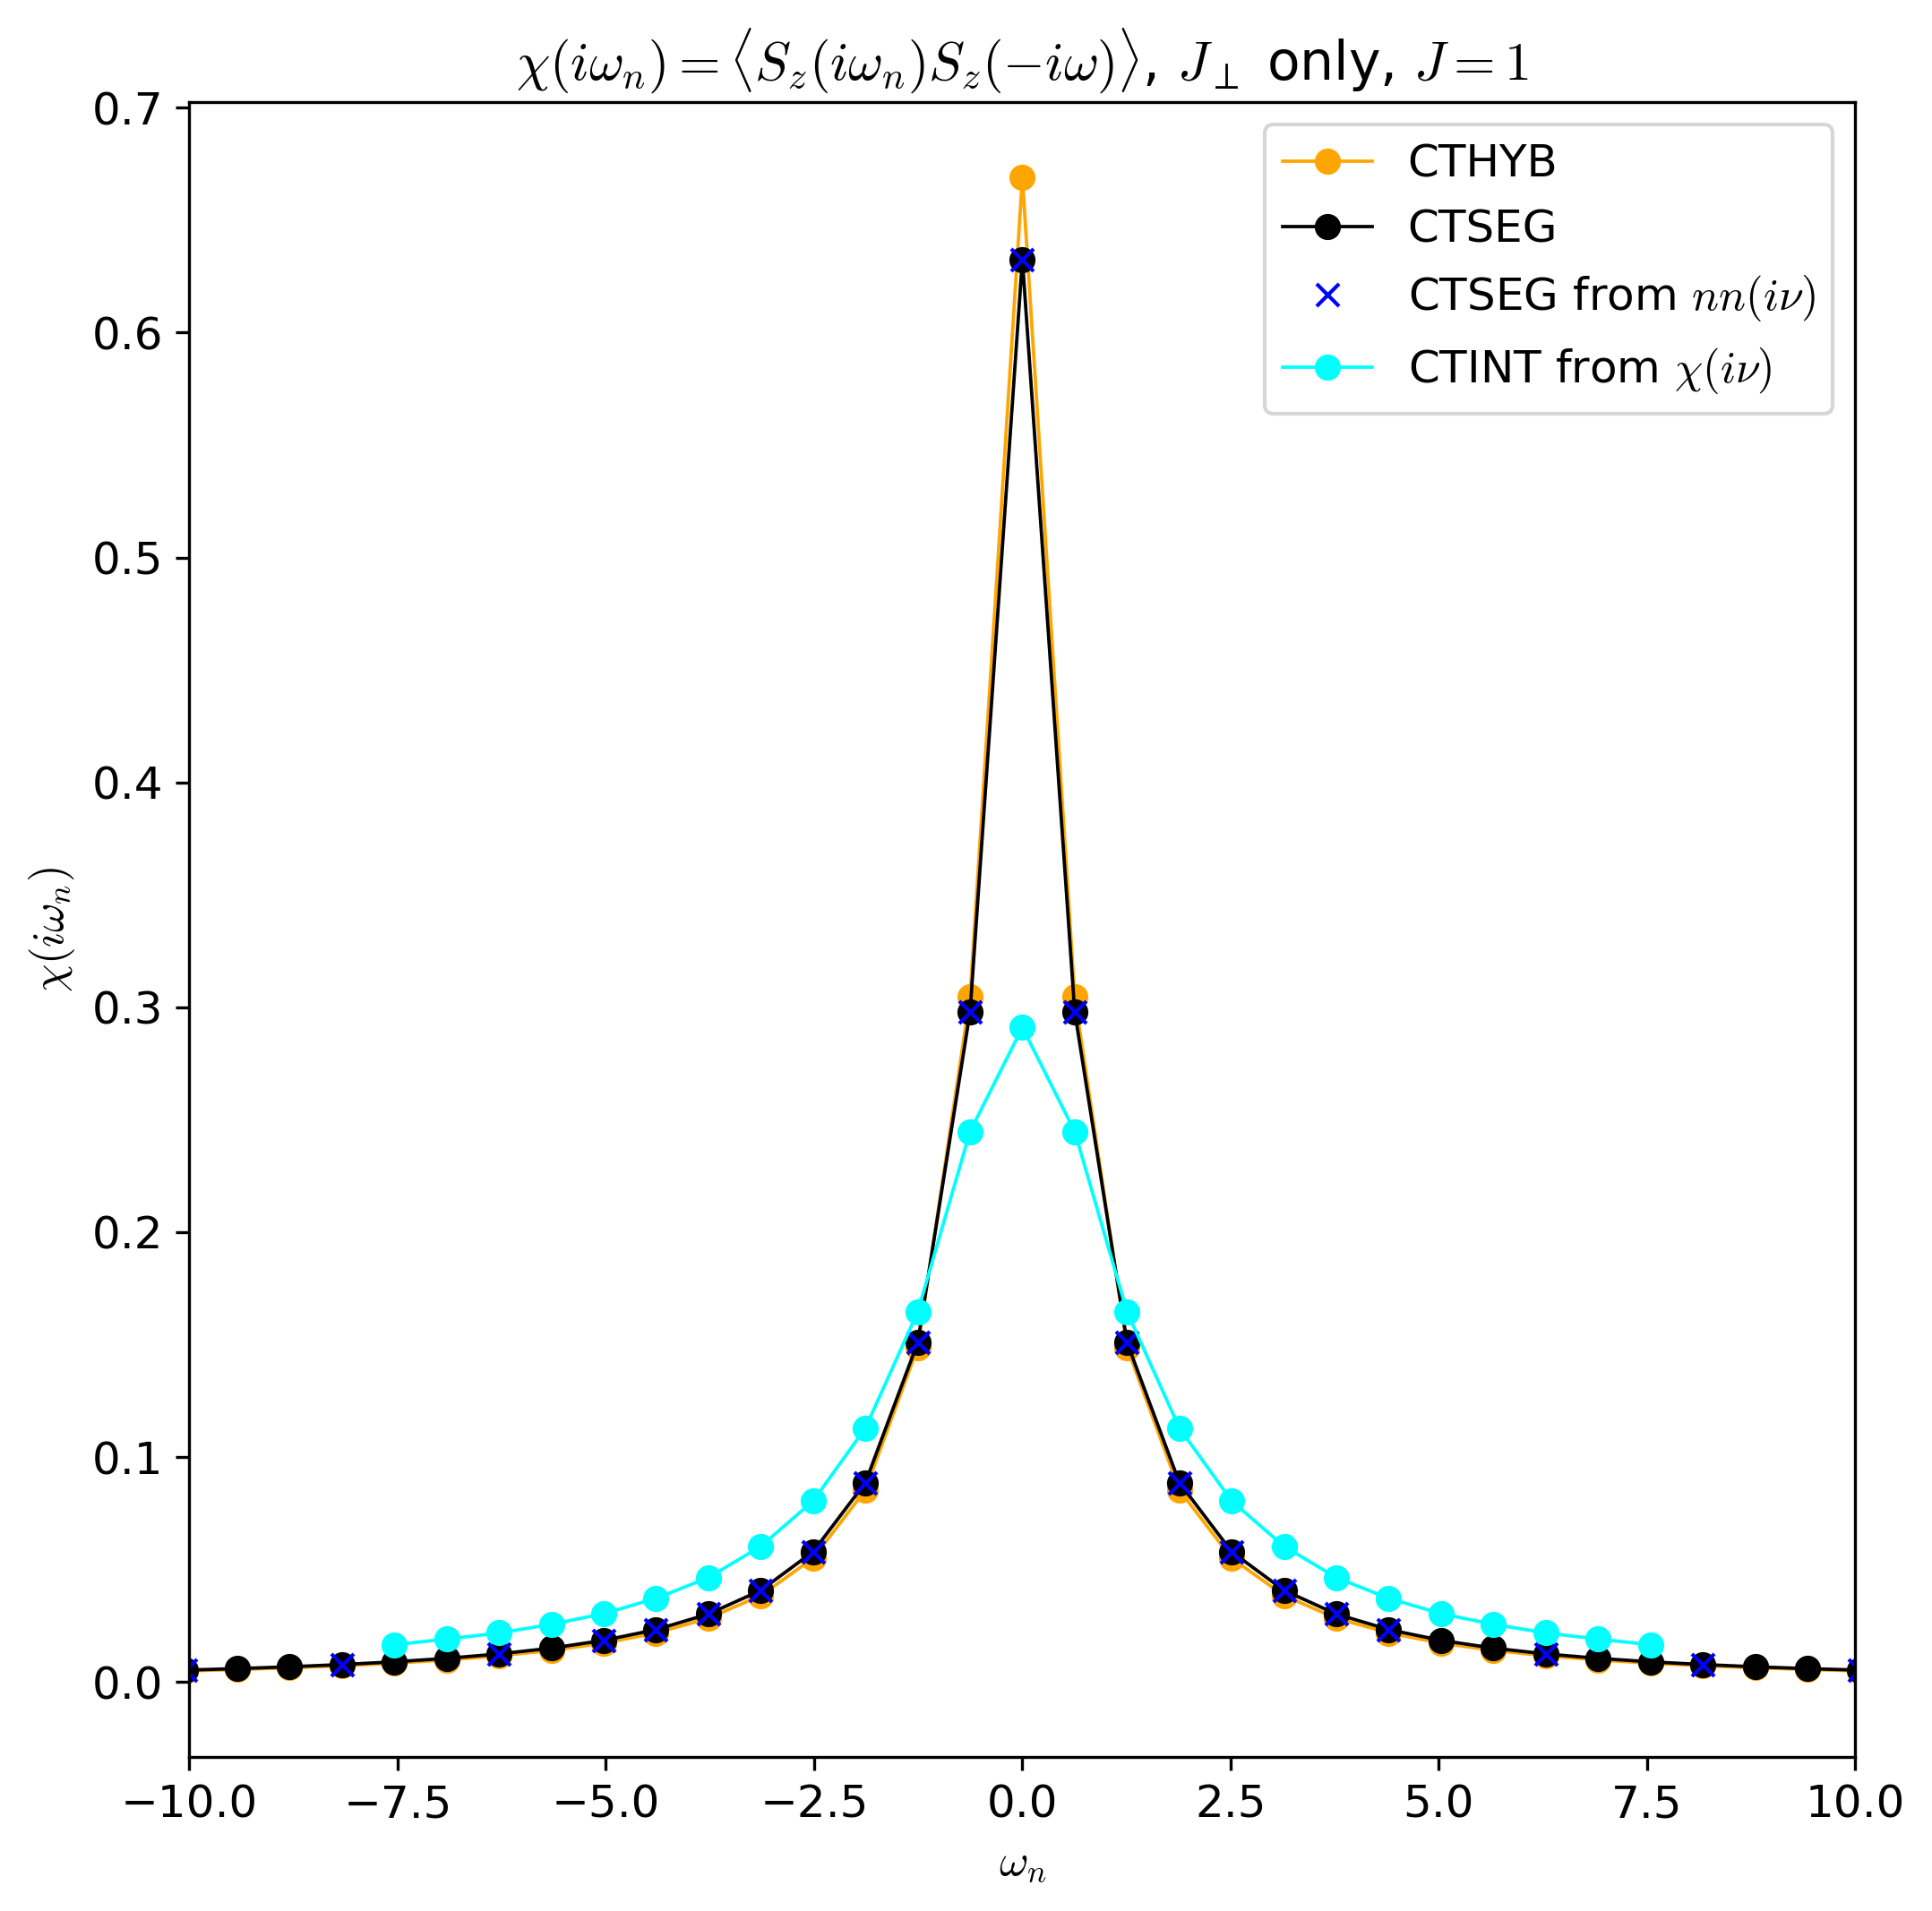

In [ ]:
Sz_nu = 0.25*(nn_nu["up", "up"   ] - nn_nu["up", "down"] - nn_nu["down", "up"] +nn_nu["down", "down"])
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
Sz_ctint = 0.25*(nn_ctint["up", "up"   ] - nn_ctint["up", "down"] - nn_ctint["down", "up"] +nn_ctint["down", "down"])
oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg.real, color="black", linewidth = 0.9, label="CTSEG")
oplot(Sz_nu.real, color="blue", linewidth = 0.9, label="CTHYB from $nn(i\\nu)$")
oplot(Sz_ctint.real, color="cyan", linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$, $J_\perp$ only, $J = 1$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

Sz_fourier = make_gf_from_fourier(Sz)
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_nu)
Sz_ctint_fourier = make_gf_from_fourier(Sz_ctint)
plt.figure(figsize=(8,8))
plt.xlim(-10,10)
oplot(Sz_fourier.real,"-o", color="orange", linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg_fourier.real, "-o",color="black",  linewidth = 0.9, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-o",color="blue",  linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
oplot(Sz_ctint_fourier.real, "-o",color="cyan",  linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(i\omega_n) =\langle S_z(i\omega_n) S_z(-i\omega) \rangle$, $J_\perp$ only, $J = 1$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend()
plt.show()

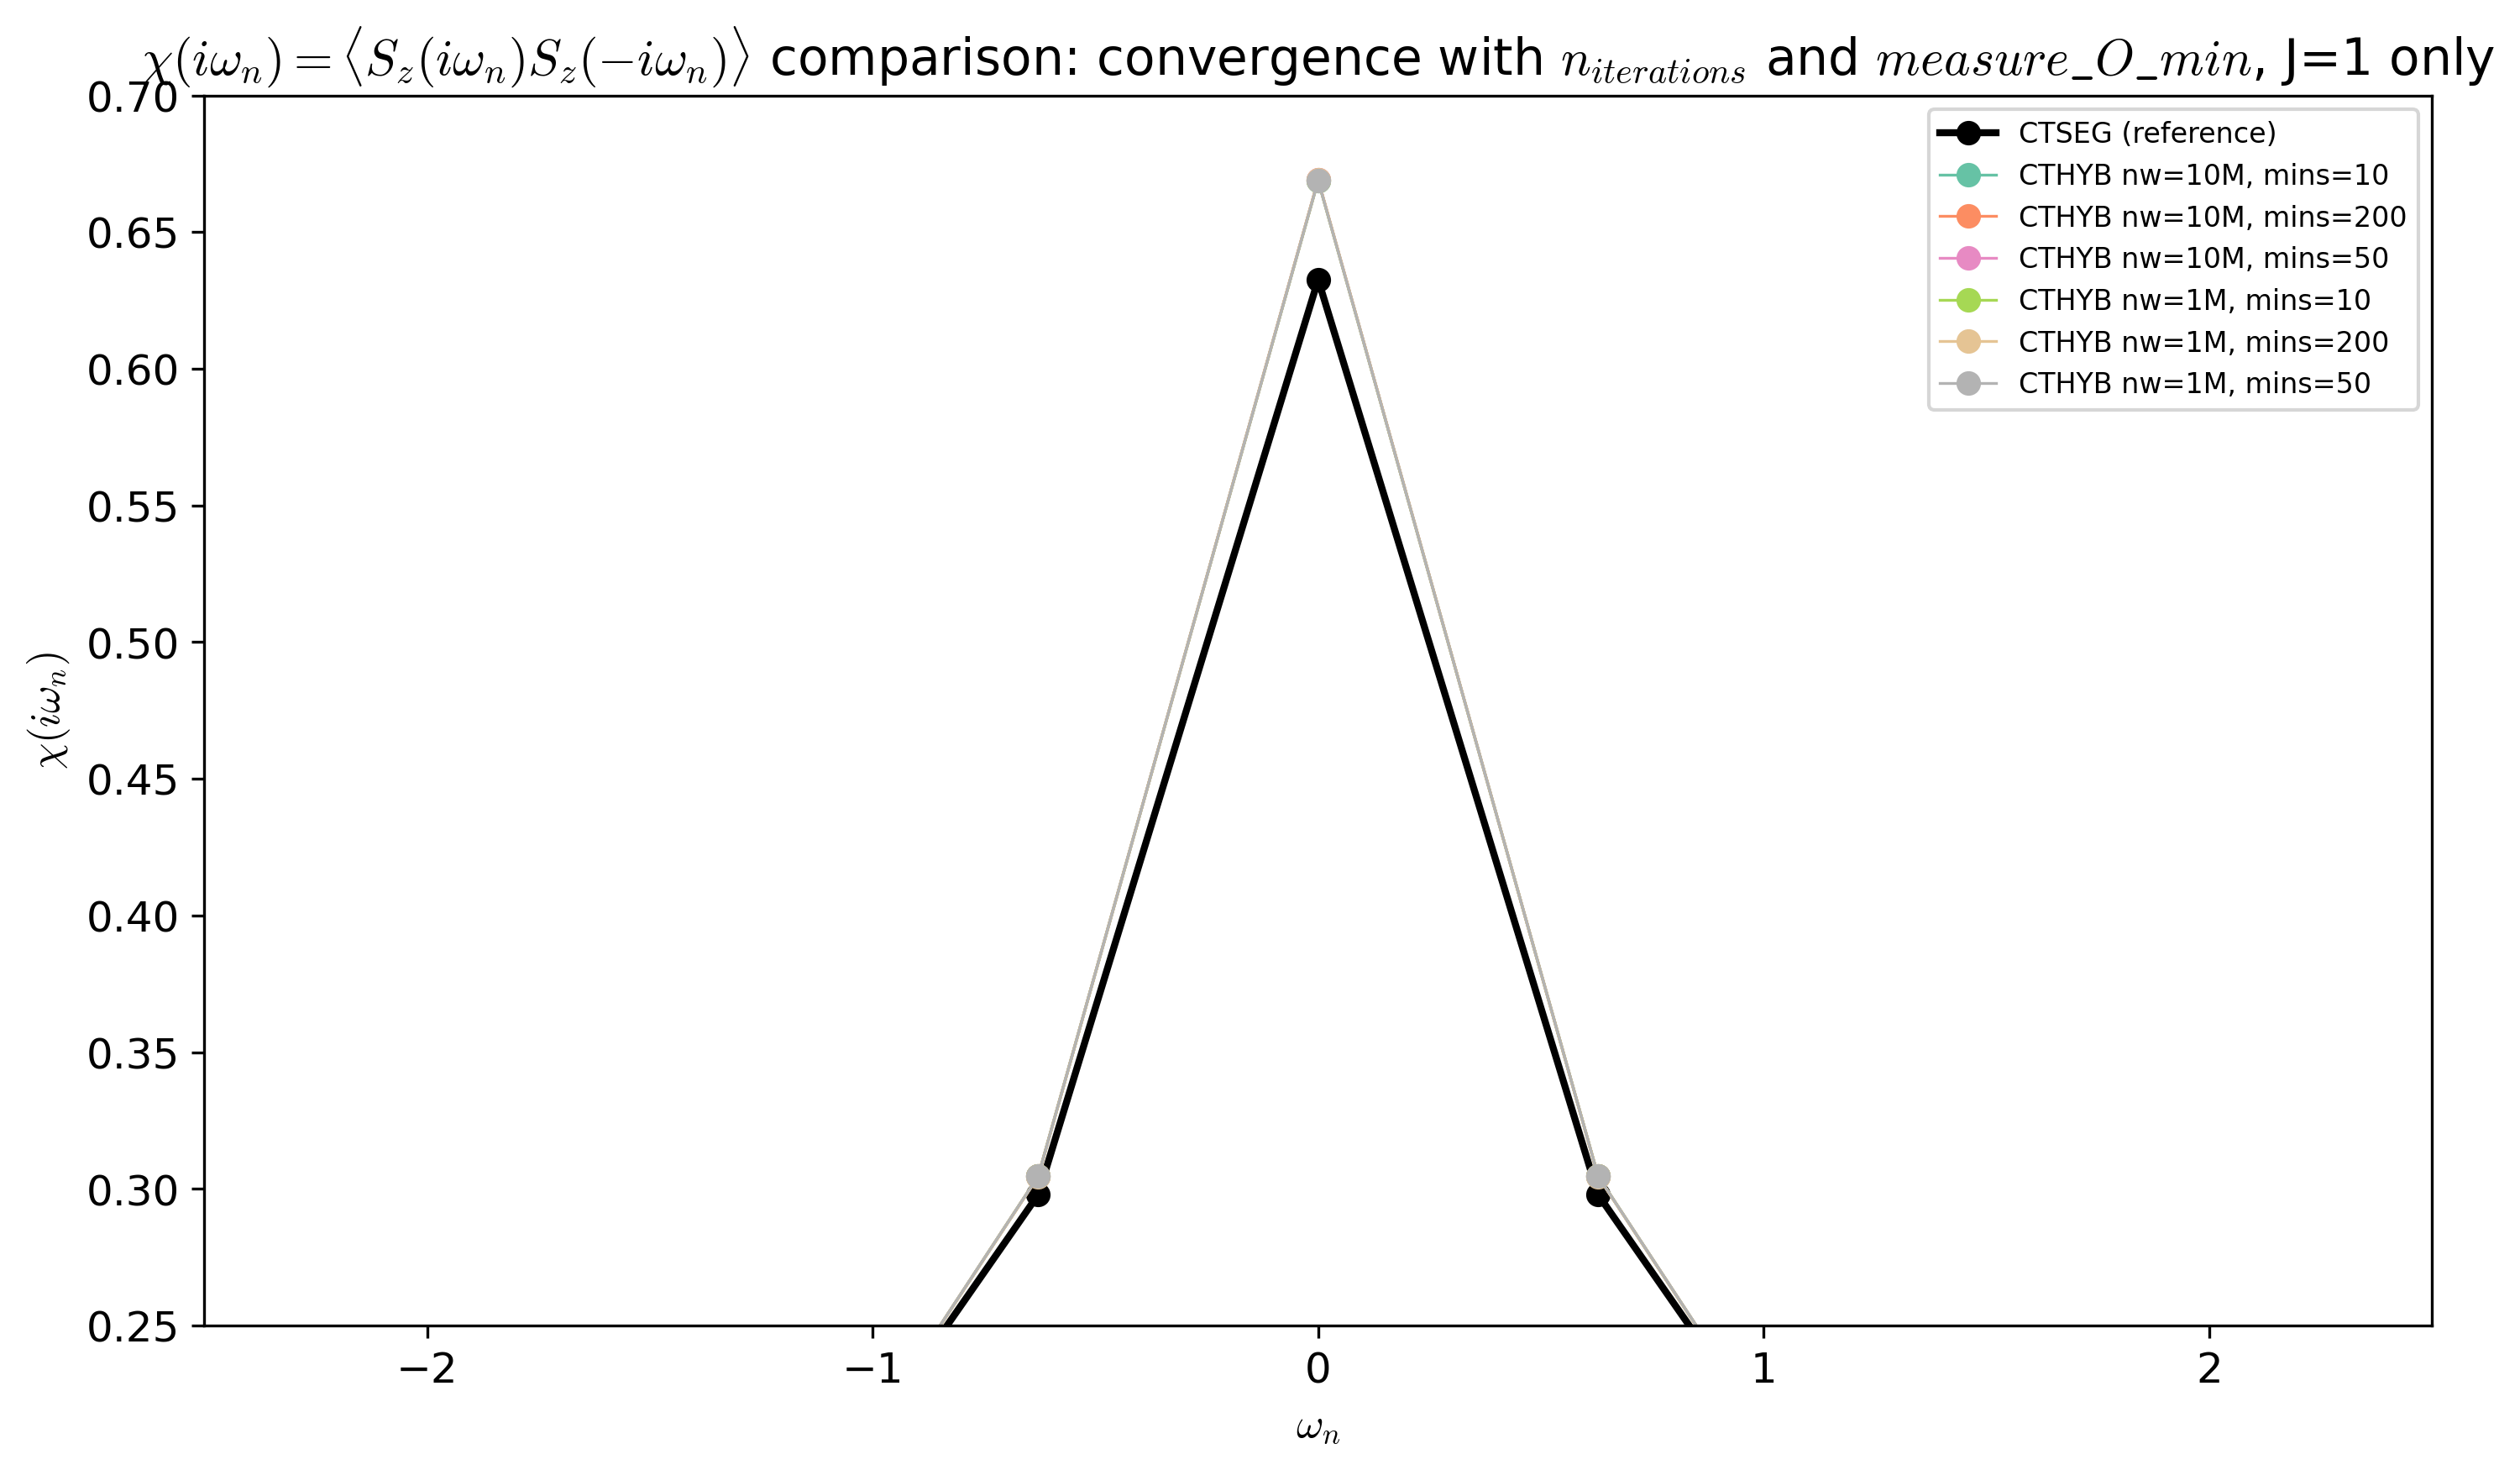

In [ ]:
# Plot Sz susceptibility comparison in frequency domain
plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(Sz_hyb_dict)))

# Fourier transform CTSEG reference
Sz_ctseg = 0.25*(nn["up", "up"] - nn["up", "down"] - nn["down", "up"] + nn["down", "down"])
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
oplot(Sz_ctseg_fourier.real, "-o", color="black", linewidth=2.0, label="CTSEG (reference)")

# Fourier transform and plot all CTHYB convergence variants
for (label, Sz), color in zip(Sz_hyb_dict.items(), colors):
    Sz_fourier = make_gf_from_fourier(Sz)
    oplot(Sz_fourier.real, "-o", color=color, linewidth=0.8, label=f"CTHYB {label}")

plt.title(r"$\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$ comparison: convergence with $n_{iterations}$ and $measure\_O\_min$, J=1 only")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.xlabel(r"$\omega_n$")
plt.xlim(-10, 10)
plt.legend(fontsize=8)
plt.tight_layout()
plt.xlim(-2.5, 2.5)
plt.ylim(0.25, 0.7)
plt.show()

### Convergence of $\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$ with number of cycles, $J = 0.25$, full dynamical interactions

nw=100K: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.824803125


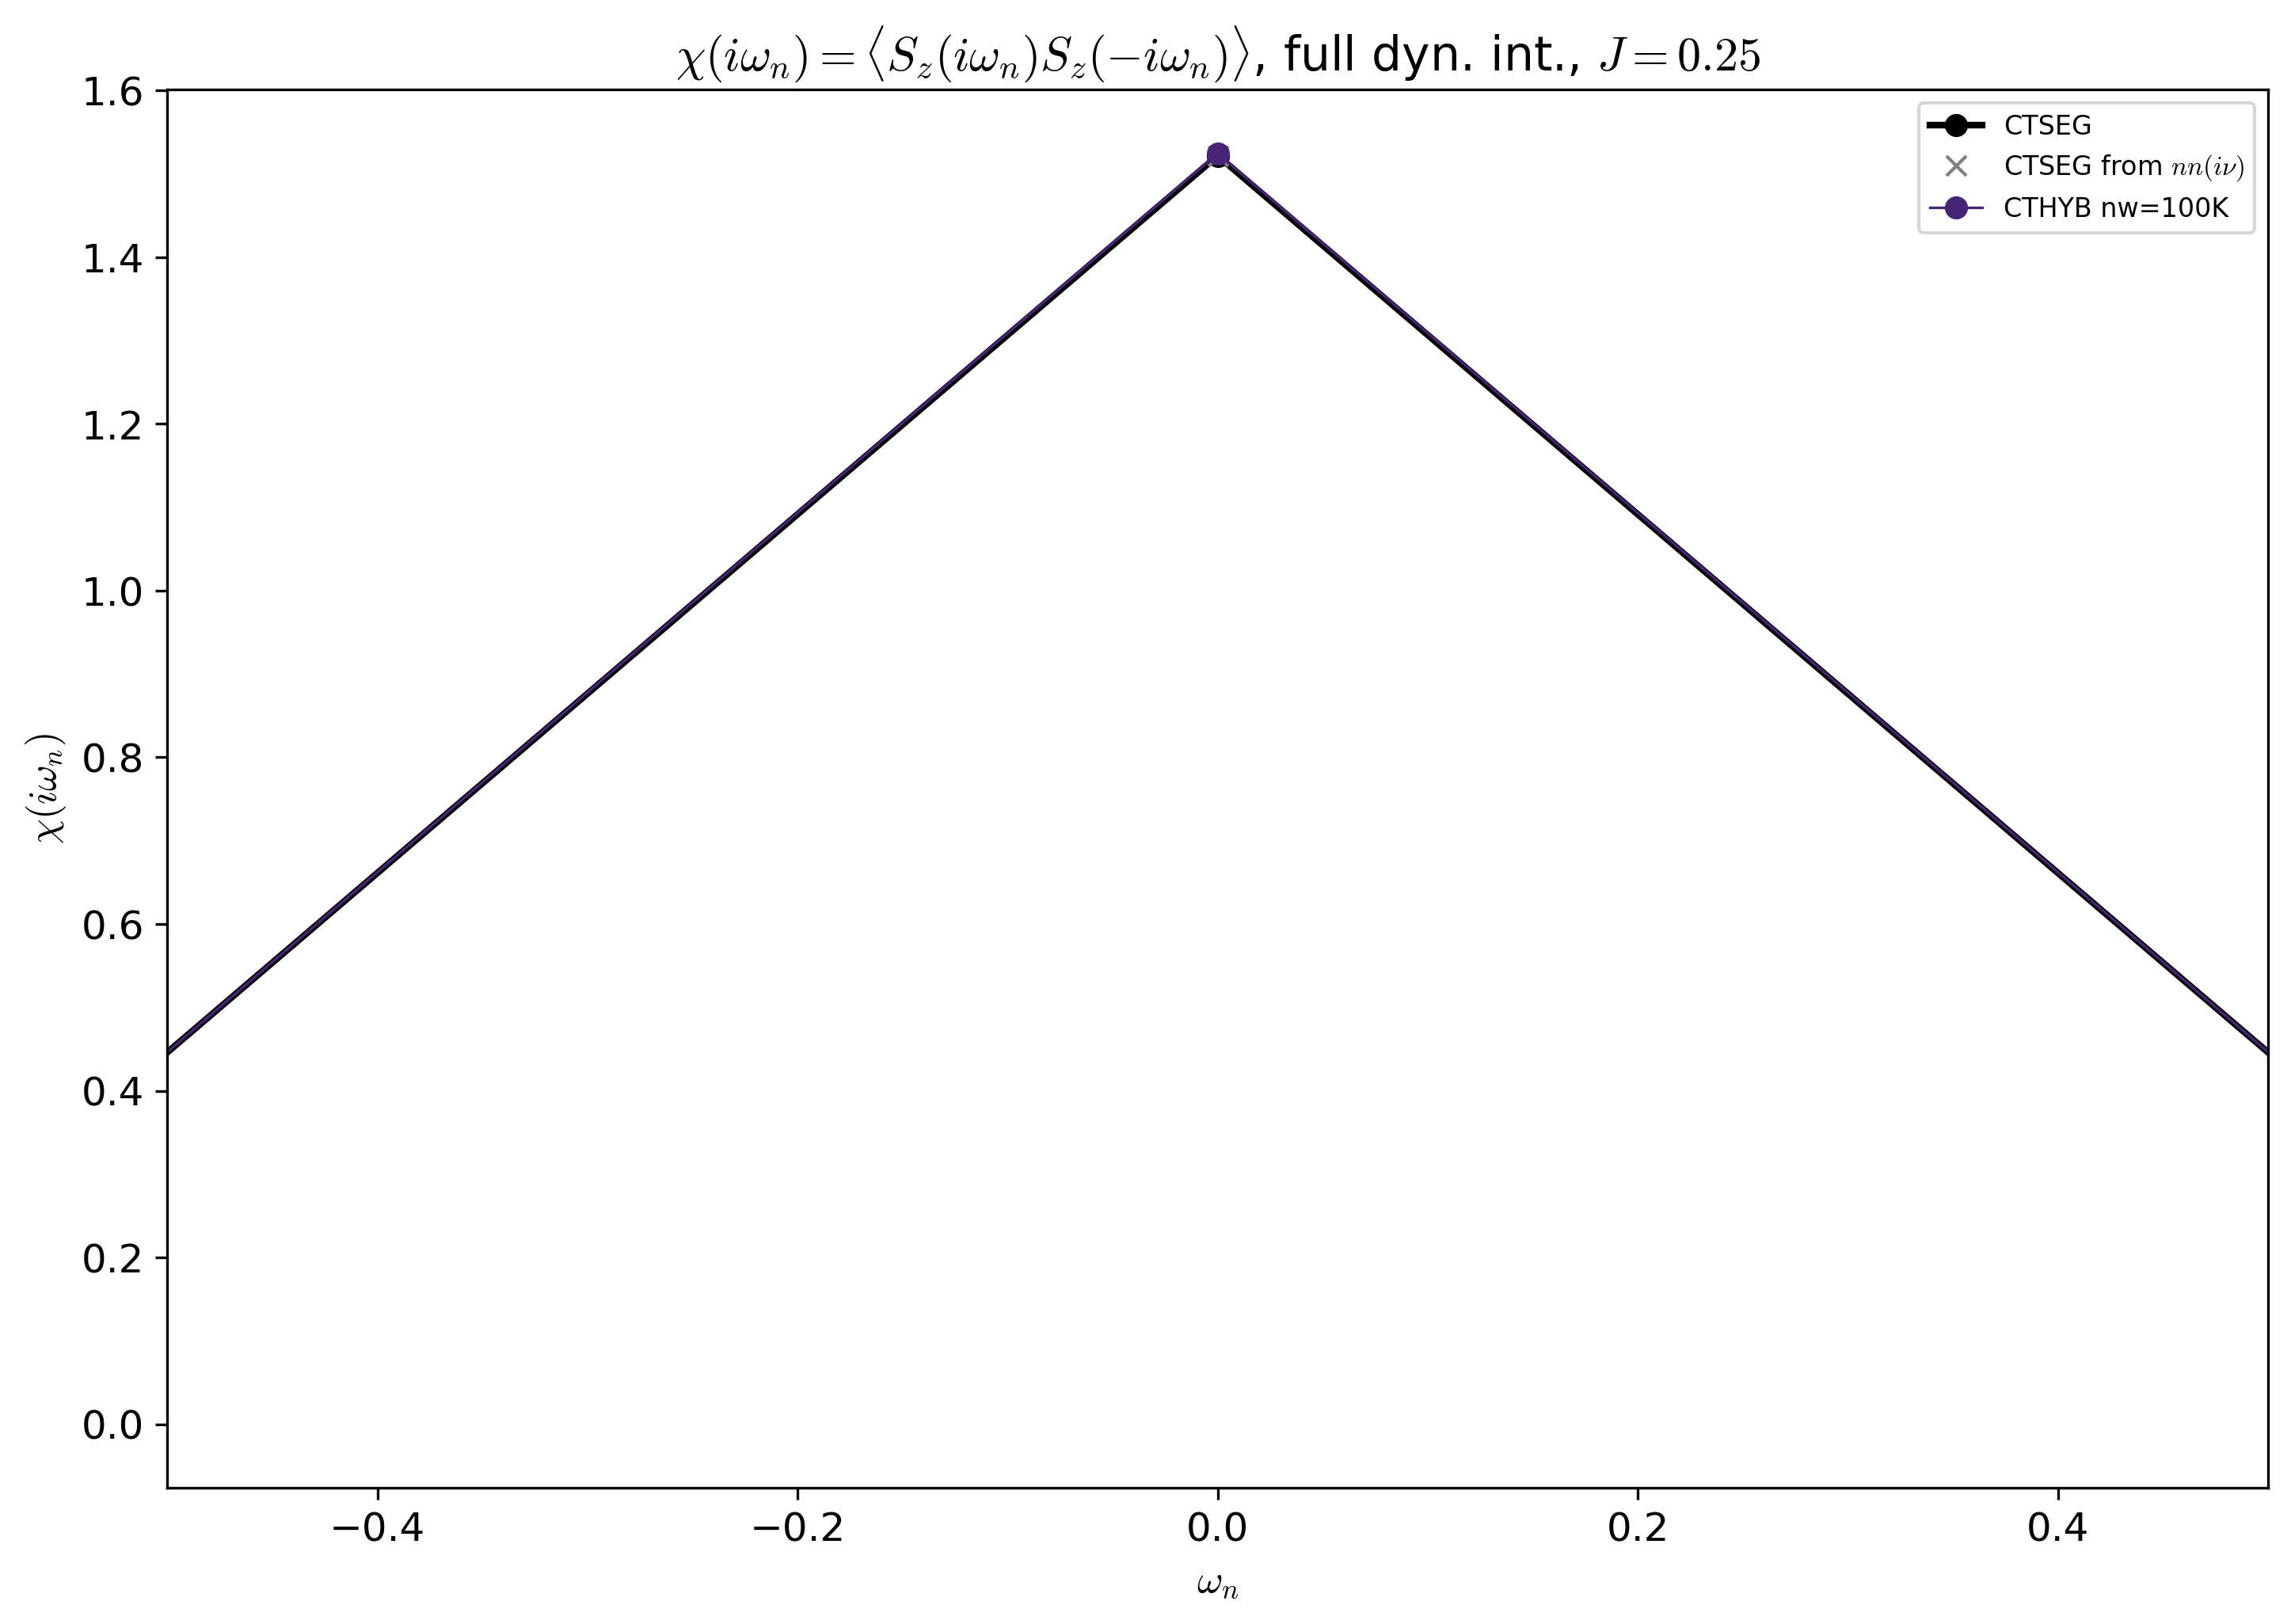

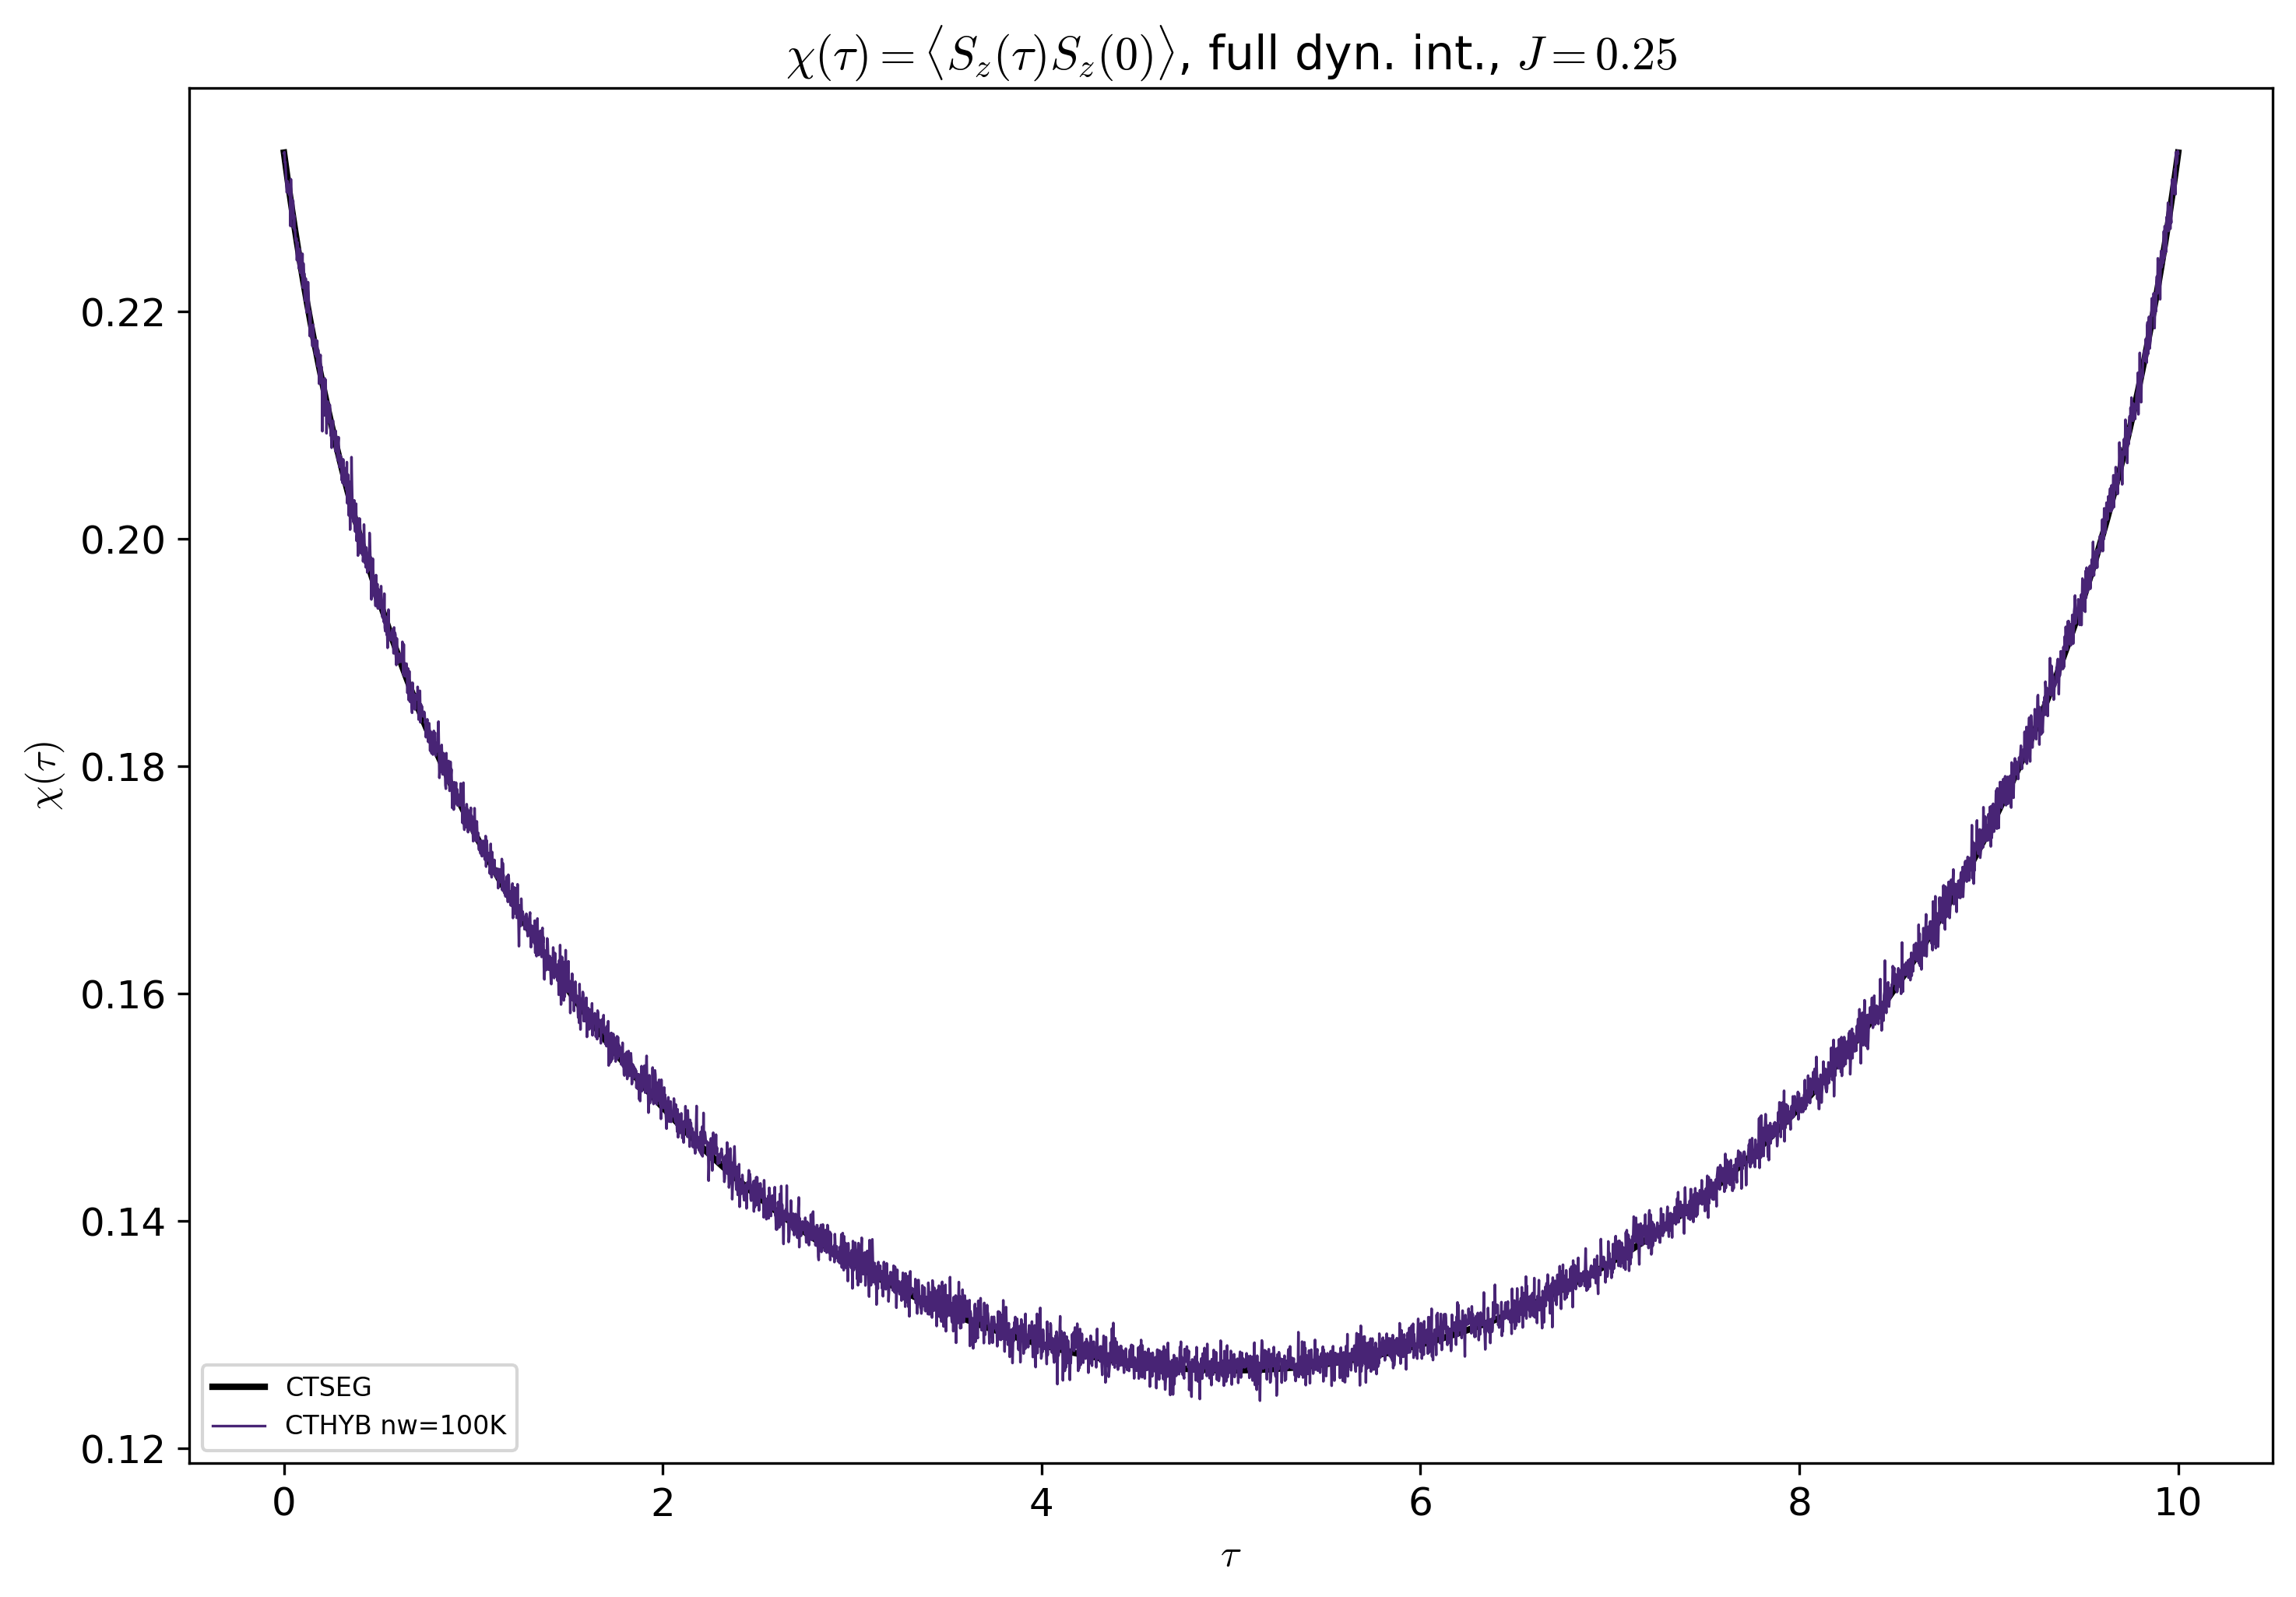

In [ ]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"

# CTSEG reference
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    nn_ref = A["nn_tau"]
    nn_iw_ref = A["nn_nu"]
    nn_nu_ref = make_gf_dlr_imtime(nn_iw_ref)

Sz_ctseg = 0.25*(nn_ref["up","up"] - nn_ref["up","down"] - nn_ref["down","up"] + nn_ref["down","down"])
Sz_ctseg_nu = 0.25*(nn_nu_ref["up","up"] - nn_nu_ref["up","down"] - nn_nu_ref["down","up"] + nn_nu_ref["down","down"])

# CTHYB files sorted by number of cycles
cthyb_files = [
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000_mins-50.h5",       "1K"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000_mins-50.h5",      "10K"),
    ("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000_mins-50.h5",    "100K"),
   #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000000_mins-50.h5",     "1M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000000_mins-50.h5",   "10M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-20000000_mins-50.h5",   "20M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-50000000_mins-50.h5",   "50M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000000_mins-50.h5", "100M"),
]

Sz_hyb = {}
for fname, label in cthyb_files:
    with HDFArchive(f"{data_loc}/{fname}", "r") as A:
        print(f"nw={label}: keys={A.keys()}, avg_sign={A['average_sign']}")
        Sz_hyb[label] = A["O_tau"]

# --- Frequency domain plot ---
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cthyb_files)))

Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_ctseg_nu)
oplot(Sz_ctseg_fourier.real, "-o", color="black", linewidth=2.0, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-s", color="gray", linewidth=1.5, label=r"CTSEG from $nn(i\nu)$")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    Sz_fourier = make_gf_from_fourier(Sz)
    oplot(Sz_fourier.real, "-o", color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.xlim(-10, 10)
plt.title(r"$\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$, full dyn. int., $J = 0.25$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.xlim(-0.5,0.5)

plt.show()

# --- Tau domain plot ---
plt.figure(figsize=(10, 7))
oplot(Sz_ctseg.real, color="black", linewidth=2.0, label="CTSEG")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    oplot(Sz.real, color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.title(r"$\chi(\tau) = \langle S_z(\tau) S_z(0) \rangle$, full dyn. int., $J = 0.25$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

nw=100K: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.2991709375
nw=1M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.299608
nw=20M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.299528775
nw=50M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.2995407675
nw=100M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.2995313075


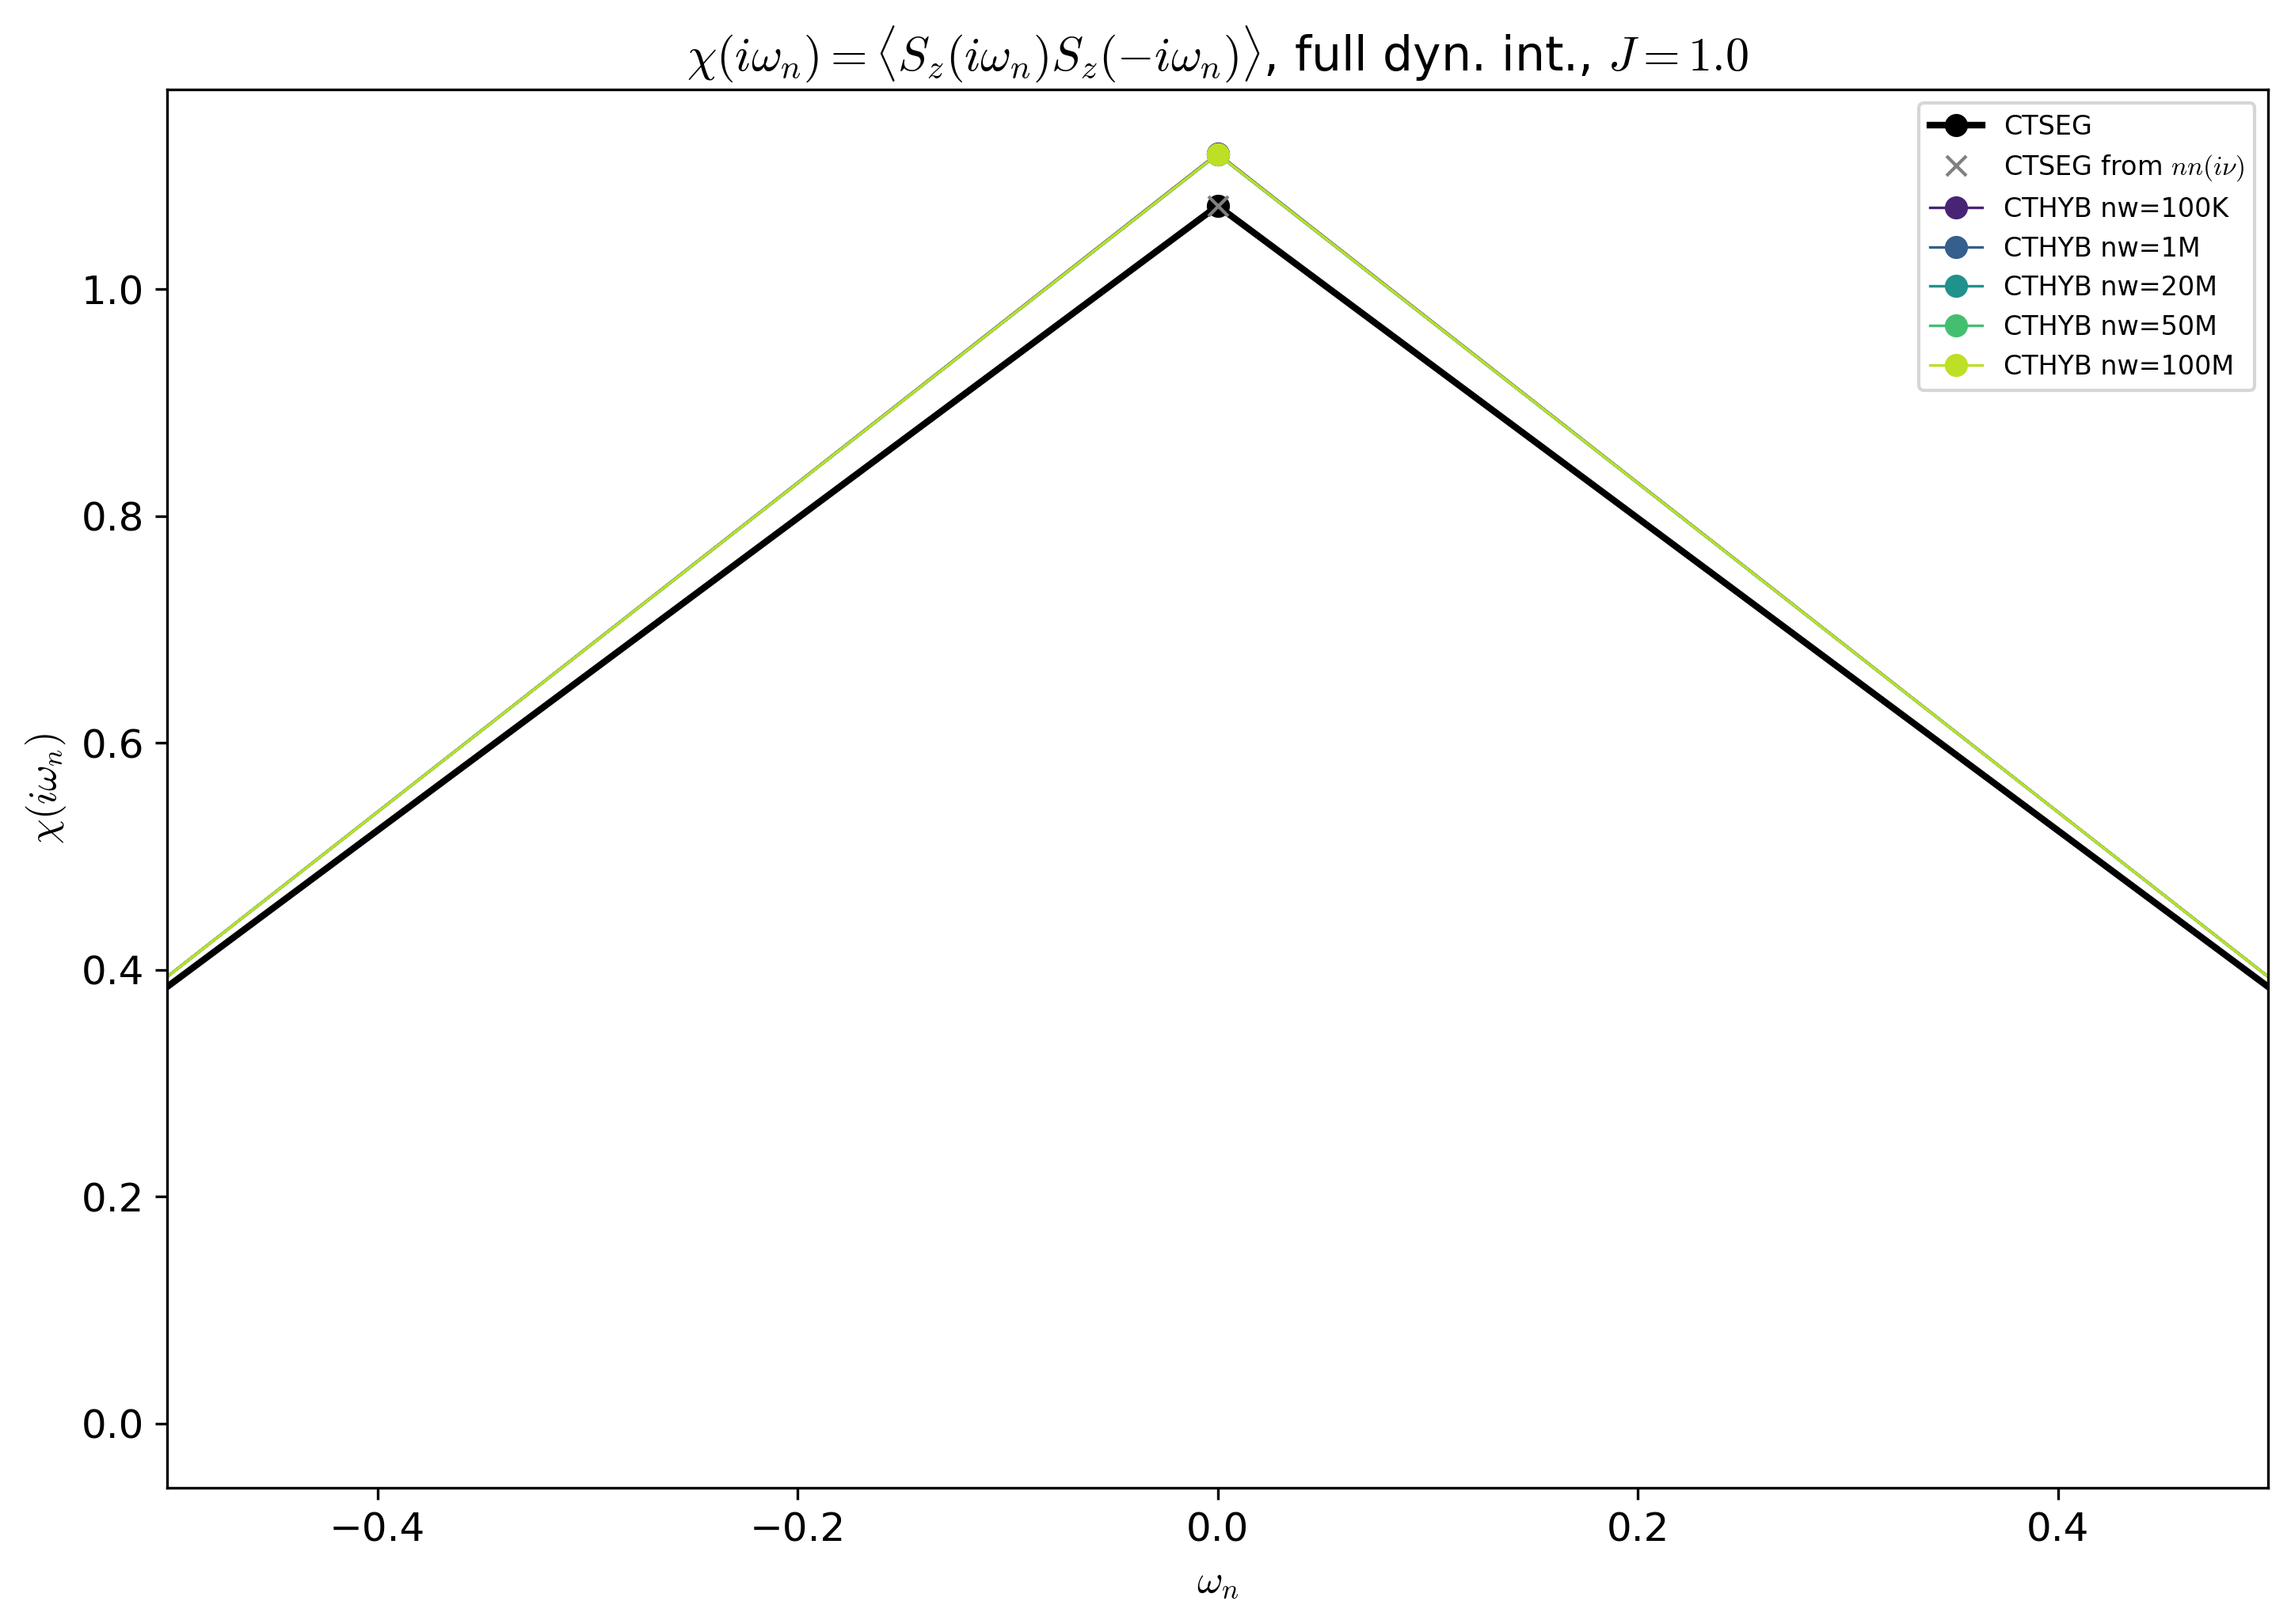

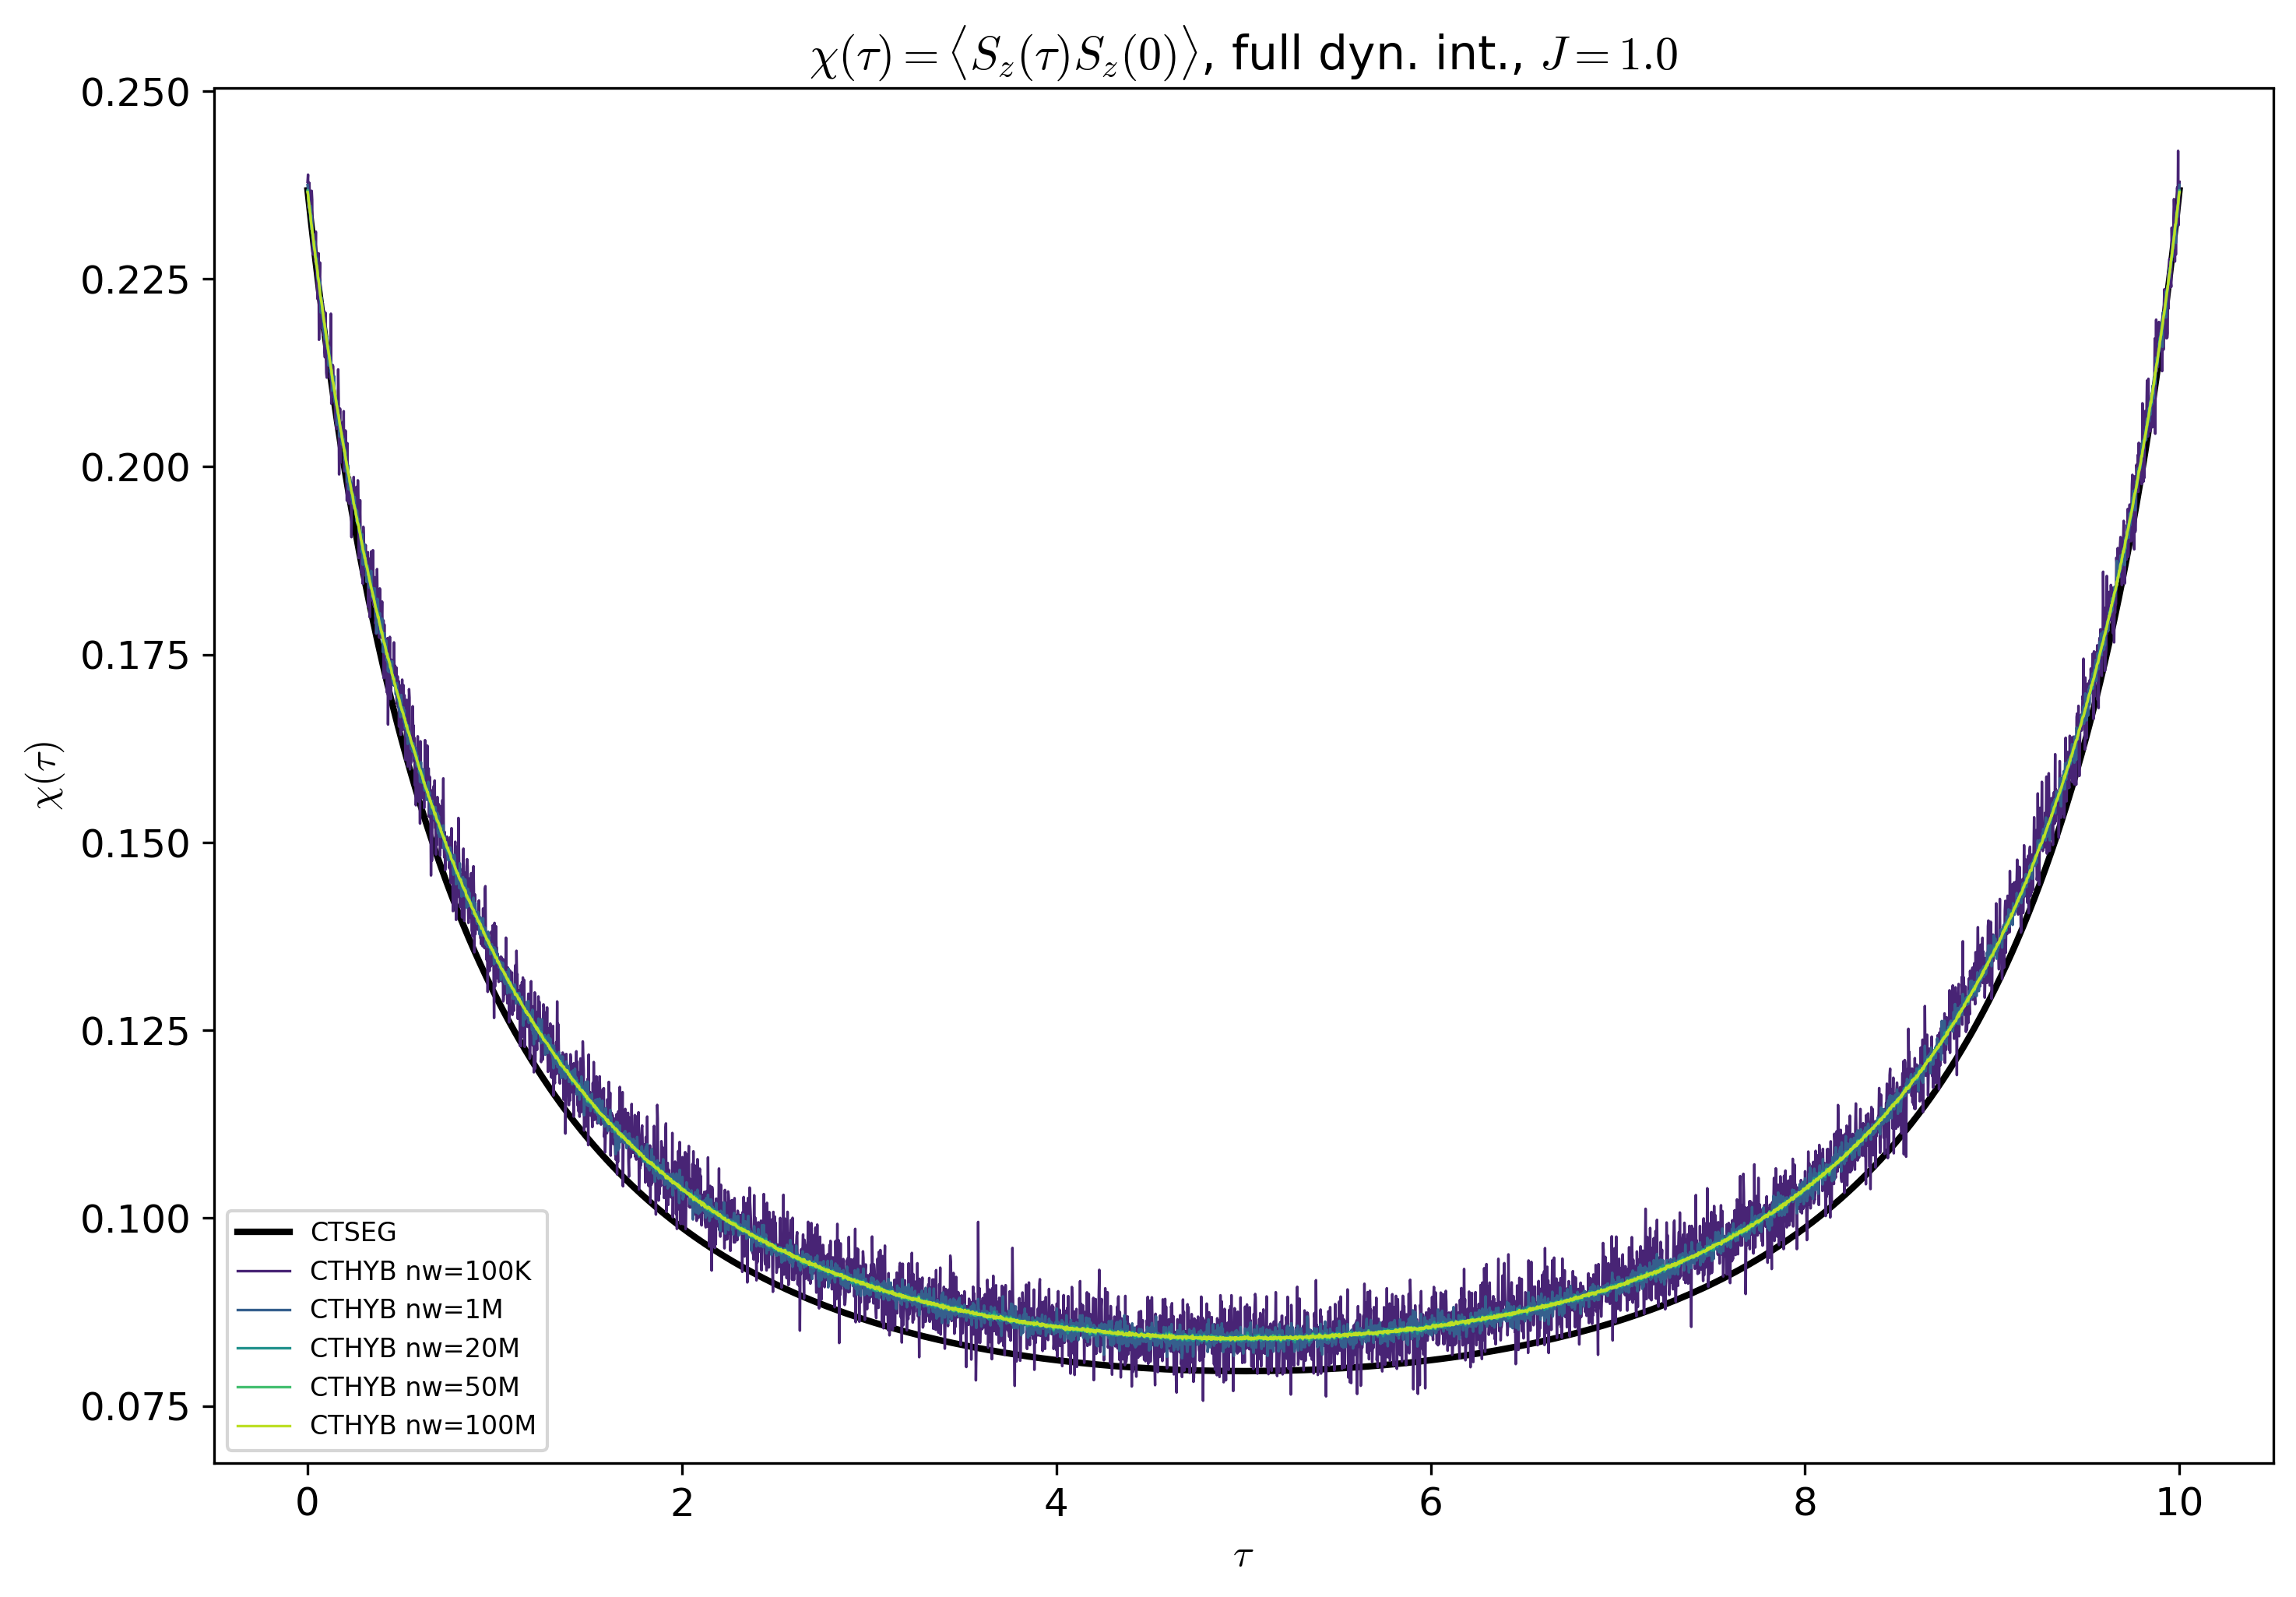

In [ ]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"

# CTSEG reference
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    nn_ref = A["nn_tau"]
    nn_iw_ref = A["nn_nu"]
    nn_nu_ref = make_gf_dlr_imtime(nn_iw_ref)

Sz_ctseg = 0.25*(nn_ref["up","up"] - nn_ref["up","down"] - nn_ref["down","up"] + nn_ref["down","down"])
Sz_ctseg_nu = 0.25*(nn_nu_ref["up","up"] - nn_nu_ref["up","down"] - nn_nu_ref["down","up"] + nn_nu_ref["down","down"])

# CTHYB files sorted by number of cycles
cthyb_files = [
    #("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000_mins-50.h5",       "1K"),
    #("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000_mins-50.h5",      "10K"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000_mins-50.h5",    "100K"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000000_mins-50.h5",     "1M"),
    #("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000000_mins-50.h5",   "10M"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-20000000_mins-50.h5",   "20M"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-50000000_mins-50.h5",   "50M"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000000_mins-50.h5", "100M"),
]

Sz_hyb = {}
for fname, label in cthyb_files:
    with HDFArchive(f"{data_loc}/{fname}", "r") as A:
        print(f"nw={label}: keys={A.keys()}, avg_sign={A['average_sign']}")
        Sz_hyb[label] = A["O_tau"]

# --- Frequency domain plot ---
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cthyb_files)))

Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_ctseg_nu)
oplot(Sz_ctseg_fourier.real, "-o", color="black", linewidth=2.0, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-s", color="gray", linewidth=1.5, label=r"CTSEG from $nn(i\nu)$")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    Sz_fourier = make_gf_from_fourier(Sz)
    oplot(Sz_fourier.real, "-o", color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.xlim(-10, 10)
plt.title(r"$\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$, full dyn. int., $J = 1.0$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.xlim(-0.5,0.5)

plt.show()

# --- Tau domain plot ---
plt.figure(figsize=(10, 7))
oplot(Sz_ctseg.real, color="black", linewidth=2.0, label="CTSEG")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    oplot(Sz.real, color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.title(r"$\chi(\tau) = \langle S_z(\tau) S_z(0) \rangle$, full dyn. int., $J = 1.0$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()